In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats.mstats import winsorize
from scipy.stats import chi2_contingency

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.svm import SVR
from sklearn.model_selection import TimeSeriesSplit

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

In [25]:
# Load Data Polis
df_polis = pd.read_csv('Data_Polis.csv')

print("=" * 50)
print("DATA POLIS")
print("=" * 50)
display(df_polis.head())
print(f"\nShape: {df_polis.shape}")
print(df_polis.info())

# Load Data Klaim
df_klaim = pd.read_csv('Data_Klaim.csv')

print("\n" + "=" * 50)
print("DATA KLAIM")
print("=" * 50)
display(df_klaim.head())
print(f"\nShape: {df_klaim.shape}")
print(df_klaim.info())

DATA POLIS


,Nomor Polis,Plan Code,Gender,Tanggal Lahir,Tanggal Efektif Polis,Domisili
0,POL-0001,M-003,M,19640811,20140603,JAKARTA
1,POL-0002,M-003,M,19710730,20140603,JAKARTA
2,POL-0003,M-001,M,19790821,20160808,JAKARTA
3,POL-0004,M-003,M,20140724,20160811,JAKARTA
4,POL-0005,M-001,F,19810114,20150828,JAKARTA



Shape: (4096, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4096 entries, 0 to 4095
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Nomor Polis            4096 non-null   object
 1   Plan Code              4096 non-null   object
 2   Gender                 4096 non-null   object
 3   Tanggal Lahir          4096 non-null   int64 
 4   Tanggal Efektif Polis  4096 non-null   int64 
 5   Domisili               4096 non-null   object
dtypes: int64(2), object(4)
memory usage: 192.1+ KB
None

DATA KLAIM


,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS
0,C-0001-M,POL-0176,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,2024-07-08,2024-05-27,2024-05-27,28093653.0,6.143948e+06,Singapore
1,C-0002-M,POL-3288,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-08-06,2024-07-15,2024-07-15,80987278.0,8.230952e+07,Malaysia
2,C-0003-M,POL-1786,R,OP,C18.9,"MALIGNANT NEOPLASM, COLON, UNSPECIFIED",PAID,2024-10-17,2024-05-16,2024-05-16,183047130.0,1.928599e+08,Singapore
3,C-0004-M,POL-1786,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-09-03,2024-07-18,2024-07-18,191424386.0,1.914244e+08,Singapore
4,C-0005-M,POL-2778,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,NaN,2024-06-06,2024-06-06,138936357.0,1.389364e+08,Singapore



Shape: (4627, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4627 entries, 0 to 4626
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Claim ID                       4627 non-null   object 
 1   Nomor Polis                    4627 non-null   object 
 2   Reimburse/Cashless             4627 non-null   object 
 3   Inpatient/Outpatient           4590 non-null   object 
 4   ICD Diagnosis                  4621 non-null   object 
 5   ICD Description                4621 non-null   object 
 6   Status Klaim                   4627 non-null   object 
 7   Tanggal Pembayaran Klaim       4590 non-null   object 
 8   Tanggal Pasien Masuk RS        4627 non-null   object 
 9   Tanggal Pasien Keluar RS       4627 non-null   object 
 10  Nominal Klaim Yang Disetujui   4627 non-null   float64
 11  Nominal Biaya RS Yang Terjadi  4627 non-null   float64
 12  Lokasi RS                    

MISSING VALUES — DATA POLIS
✅ Tidak ada missing value

MISSING VALUES — DATA KLAIM
Inpatient/Outpatient        37
ICD Diagnosis                6
ICD Description              6
Tanggal Pembayaran Klaim    37
Lokasi RS                    7
dtype: int64


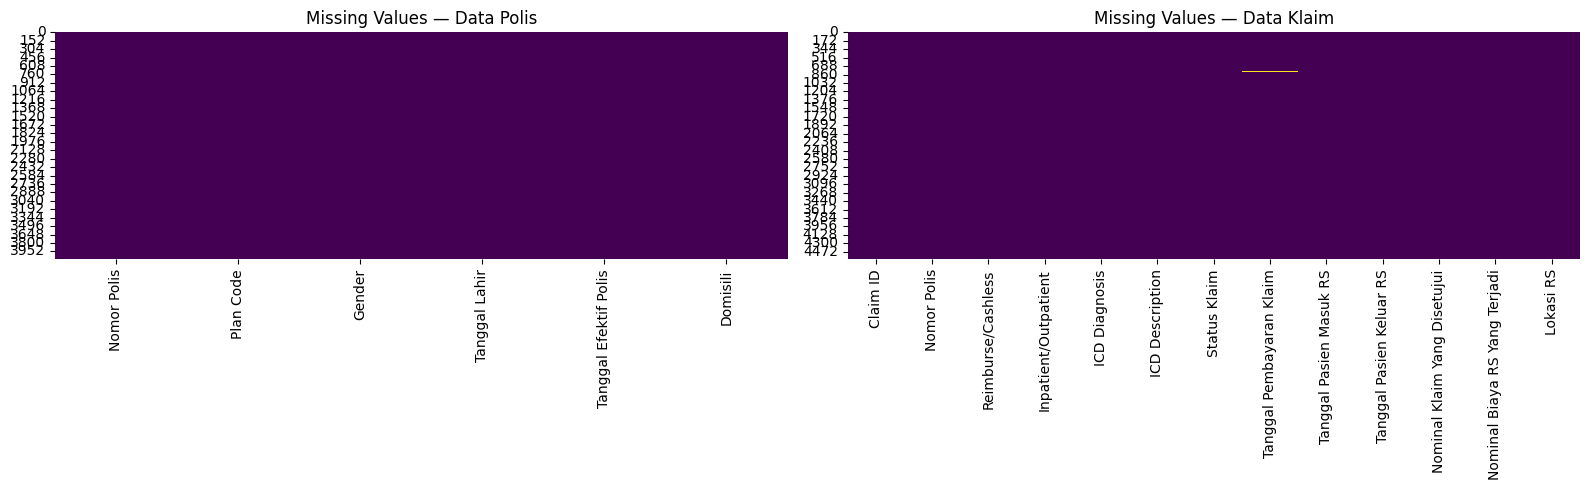


✅ Data klaim setelah filter PAID: 4627 rows
✅ Duplikat dihapus: 0 rows

✅ Cell 3 selesai


In [26]:
# ── POLIS ──────────────────────────────────────────────
df_polis['Tanggal Lahir'] = pd.to_datetime(
    df_polis['Tanggal Lahir'], format='%Y%m%d'
)
df_polis['Tanggal Efektif Polis'] = pd.to_datetime(
    df_polis['Tanggal Efektif Polis'], format='%Y%m%d'
)

# ── KLAIM ──────────────────────────────────────────────
df_klaim['Tanggal Pembayaran Klaim'] = pd.to_datetime(
    df_klaim['Tanggal Pembayaran Klaim'], errors='coerce'
)
df_klaim['Tanggal Pasien Masuk RS'] = pd.to_datetime(
    df_klaim['Tanggal Pasien Masuk RS'], errors='coerce'
)
df_klaim['Tanggal Pasien Keluar RS'] = pd.to_datetime(
    df_klaim['Tanggal Pasien Keluar RS'], errors='coerce'
)

# ── MISSING VALUES CHECK ───────────────────────────────
print("=" * 50)
print("MISSING VALUES — DATA POLIS")
print("=" * 50)
mv_polis = df_polis.isnull().sum()
print(mv_polis[mv_polis > 0] if mv_polis.sum() > 0 else "✅ Tidak ada missing value")

print("\n" + "=" * 50)
print("MISSING VALUES — DATA KLAIM")
print("=" * 50)
mv_klaim = df_klaim.isnull().sum()
print(mv_klaim[mv_klaim > 0])

# ── HEATMAP MISSING VALUES ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(df_polis.isnull(), cbar=False, cmap='viridis', ax=axes[0])
axes[0].set_title('Missing Values — Data Polis')

sns.heatmap(df_klaim.isnull(), cbar=False, cmap='viridis', ax=axes[1])
axes[1].set_title('Missing Values — Data Klaim')

plt.tight_layout()
plt.show()

# ── FILTER HANYA STATUS PAID ───────────────────────────
df_klaim = df_klaim[df_klaim['Status Klaim'] == 'PAID'].copy()
print(f"\n✅ Data klaim setelah filter PAID: {df_klaim.shape[0]} rows")

# ── DROP DUPLIKAT ──────────────────────────────────────
before = df_klaim.shape[0]
df_klaim = df_klaim.drop_duplicates(subset='Claim ID')
print(f"✅ Duplikat dihapus: {before - df_klaim.shape[0]} rows")

print("\n✅ Cell 3 selesai")

In [27]:
# ── FEATURE ENGINEERING POLIS ─────────────────────────

# Umur saat ini
reference_date = pd.Timestamp('2025-07-01')

df_polis['Umur'] = (
    (reference_date - df_polis['Tanggal Lahir']).dt.days / 365.25
).astype(int)

# Lama polis aktif (tahun)
df_polis['Lama_Polis'] = (
    (reference_date - df_polis['Tanggal Efektif Polis']).dt.days / 365.25
).round(2)

# Kelompok umur
df_polis['Kelompok_Umur'] = pd.cut(
    df_polis['Umur'],
    bins=[0, 17, 30, 45, 60, 100],
    labels=['<18', '18-30', '31-45', '46-60', '>60']
)

print("=" * 50)
print("FEATURE ENGINEERING POLIS")
print("=" * 50)
display(df_polis[['Nomor Polis', 'Umur', 'Lama_Polis', 
                   'Kelompok_Umur', 'Gender', 'Plan Code']].head(10))

# ── STATISTIK PORTFOLIO PER BULAN ─────────────────────
# Proporsi gender, plan code, umur rata-rata di portfolio aktif
# Ini akan digunakan sebagai exogenous variable di model

# Buat summary portfolio (statis karena polis tidak berubah drastis)
portfolio_stats = {
    'Pct_Female'   : (df_polis['Gender'] == 'F').mean(),
    'Avg_Umur'     : df_polis['Umur'].mean(),
    'Pct_M001'     : (df_polis['Plan Code'] == 'M-001').mean(),
    'Pct_M003'     : (df_polis['Plan Code'] == 'M-003').mean(),
    'Avg_Lama_Polis': df_polis['Lama_Polis'].mean(),
}

print("\n" + "=" * 50)
print("PORTFOLIO STATISTICS")
print("=" * 50)
for k, v in portfolio_stats.items():
    print(f"  {k}: {v:.4f}")

# ── MERGE POLIS KE KLAIM ───────────────────────────────
df_merged = df_klaim.merge(
    df_polis[['Nomor Polis', 'Gender', 'Plan Code', 
              'Umur', 'Lama_Polis', 'Kelompok_Umur']],
    on='Nomor Polis',
    how='left'
)

# Length of stay (hari rawat inap)
df_merged['Length_of_Stay'] = (
    df_merged['Tanggal Pasien Keluar RS'] - 
    df_merged['Tanggal Pasien Masuk RS']
).dt.days.clip(lower=0)

# Claim ratio (approved vs total RS cost)
df_merged['Claim_Ratio'] = (
    df_merged['Nominal Klaim Yang Disetujui'] / 
    df_merged['Nominal Biaya RS Yang Terjadi'].replace(0, np.nan)
).fillna(0).clip(0, 1)

print("\n" + "=" * 50)
print("MERGED DATA")
print("=" * 50)
print(f"Shape: {df_merged.shape}")
display(df_merged.head())

print("\n✅ Cell 4 selesai")

FEATURE ENGINEERING POLIS


,Nomor Polis,Umur,Lama_Polis,Kelompok_Umur,Gender,Plan Code
0,POL-0001,60,11.08,46-60,M,M-003
1,POL-0002,53,11.08,46-60,M,M-003
2,POL-0003,45,8.90,31-45,M,M-001
3,POL-0004,10,8.89,<18,M,M-003
4,POL-0005,44,9.84,31-45,F,M-001
5,POL-0006,69,9.01,>60,F,M-001
6,POL-0007,63,7.47,>60,F,M-003
7,POL-0008,50,8.74,46-60,F,M-002
8,POL-0009,63,7.70,>60,M,M-001
9,POL-0010,68,7.81,>60,F,M-001



PORTFOLIO STATISTICS
  Pct_Female: 0.4880
  Avg_Umur: 52.3225
  Pct_M001: 0.1392
  Pct_M003: 0.3108
  Avg_Lama_Polis: 10.3779

MERGED DATA
Shape: (4627, 20)


,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS,Gender,Plan Code,Umur,Lama_Polis,Kelompok_Umur,Length_of_Stay,Claim_Ratio
0,C-0001-M,POL-0176,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,2024-07-08,2024-05-27,2024-05-27,28093653.0,6.143948e+06,Singapore,F,M-001,58,10.48,46-60,0,1.000000
1,C-0002-M,POL-3288,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-08-06,2024-07-15,2024-07-15,80987278.0,8.230952e+07,Malaysia,M,M-002,68,13.03,>60,0,0.983936
2,C-0003-M,POL-1786,R,OP,C18.9,"MALIGNANT NEOPLASM, COLON, UNSPECIFIED",PAID,2024-10-17,2024-05-16,2024-05-16,183047130.0,1.928599e+08,Singapore,F,M-002,65,10.29,>60,0,0.949120
3,C-0004-M,POL-1786,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-09-03,2024-07-18,2024-07-18,191424386.0,1.914244e+08,Singapore,F,M-002,65,10.29,>60,0,1.000000
4,C-0005-M,POL-2778,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,NaT,2024-06-06,2024-06-06,138936357.0,1.389364e+08,Singapore,F,M-002,56,11.02,46-60,0,1.000000



✅ Cell 4 selesai


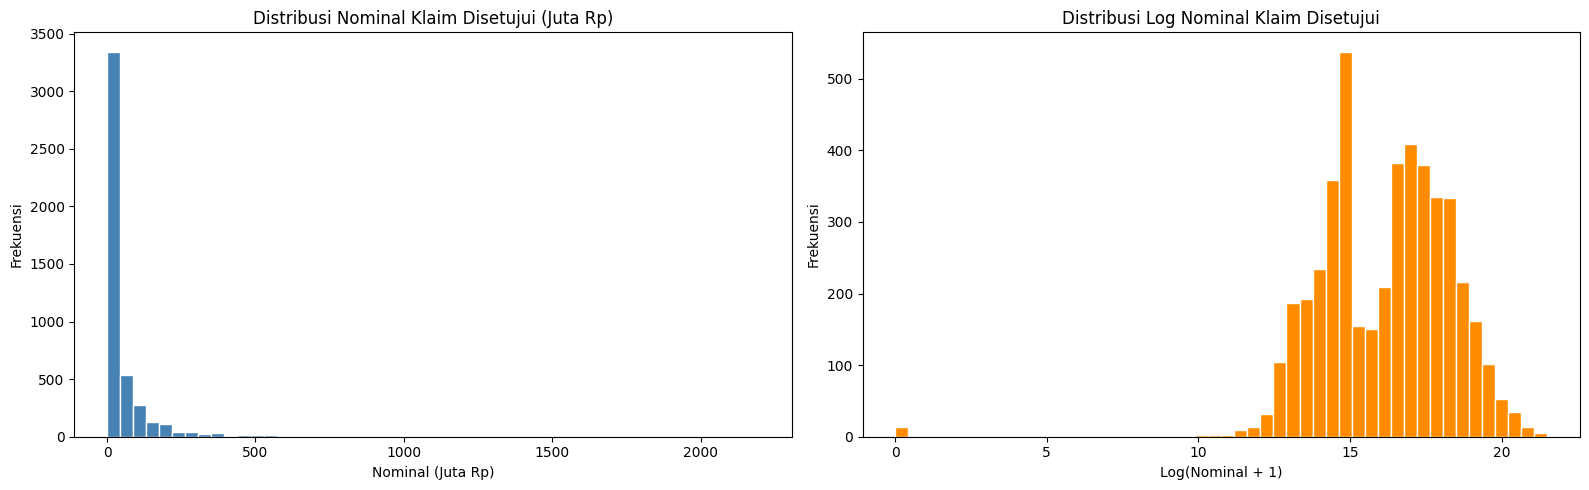

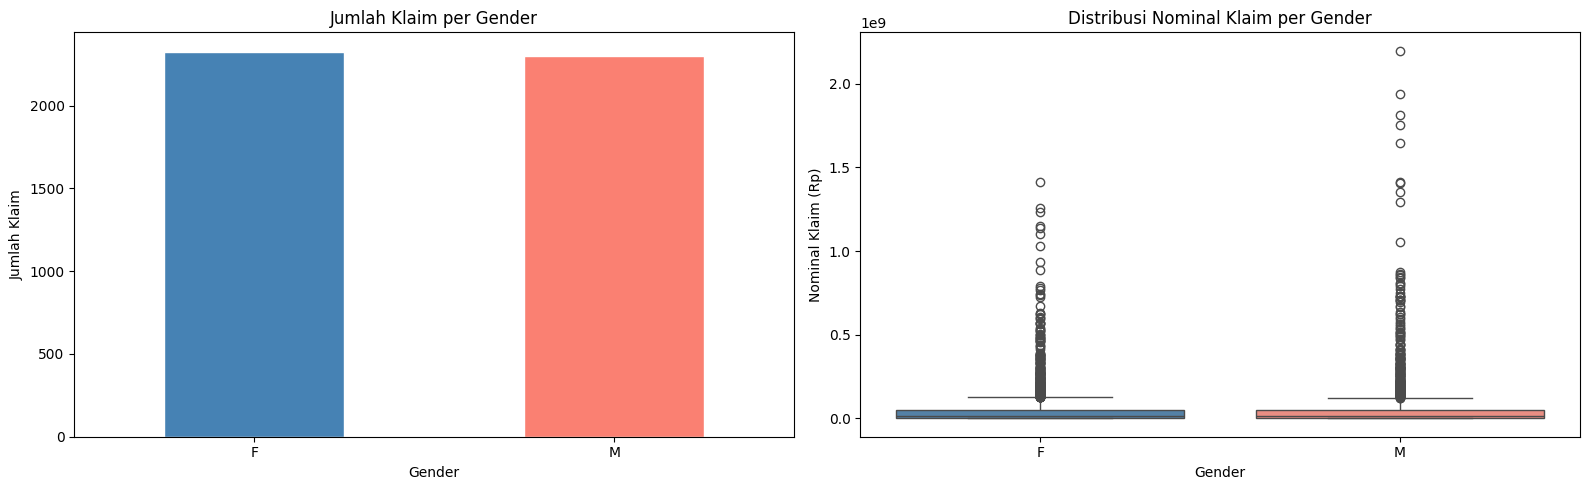

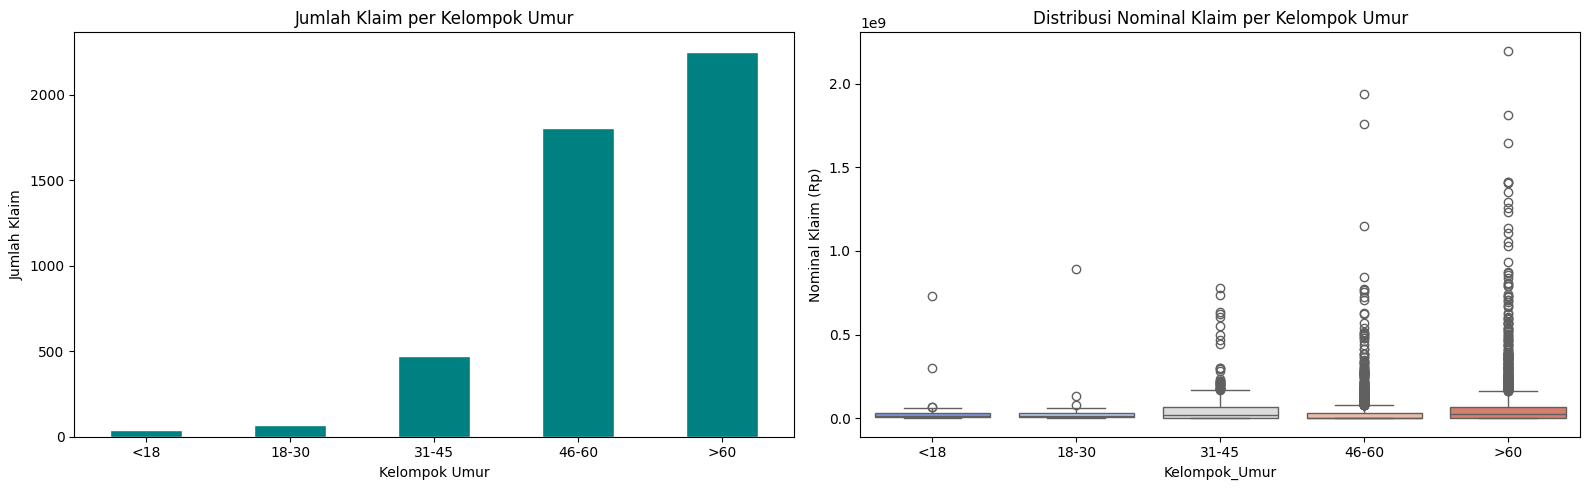

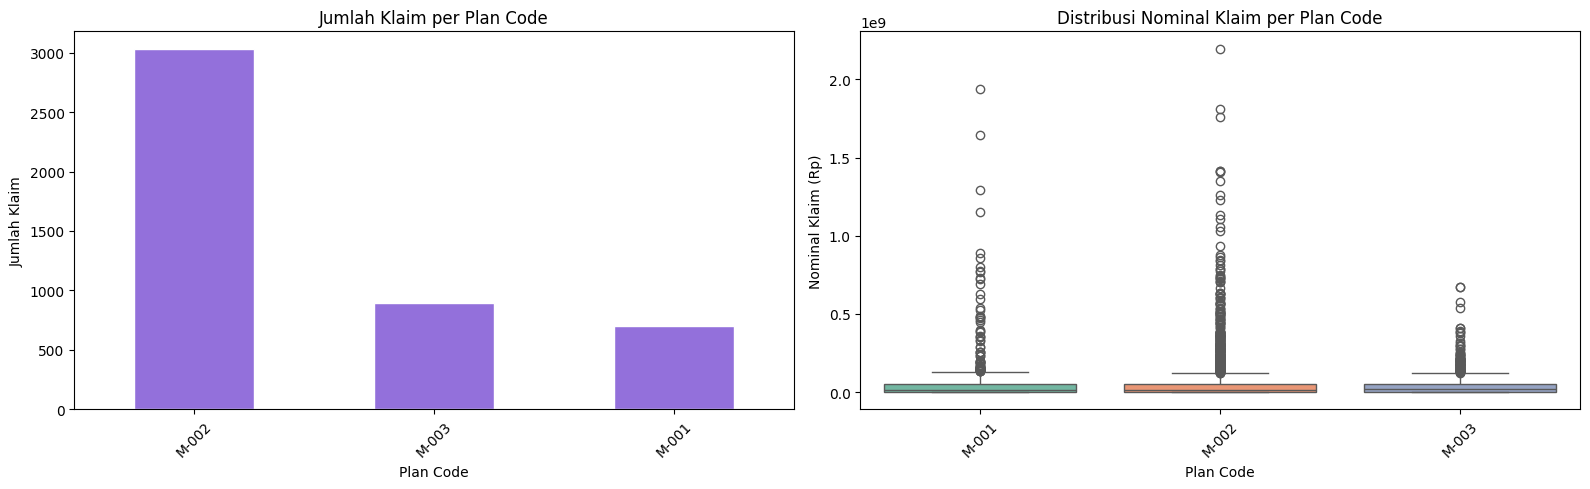

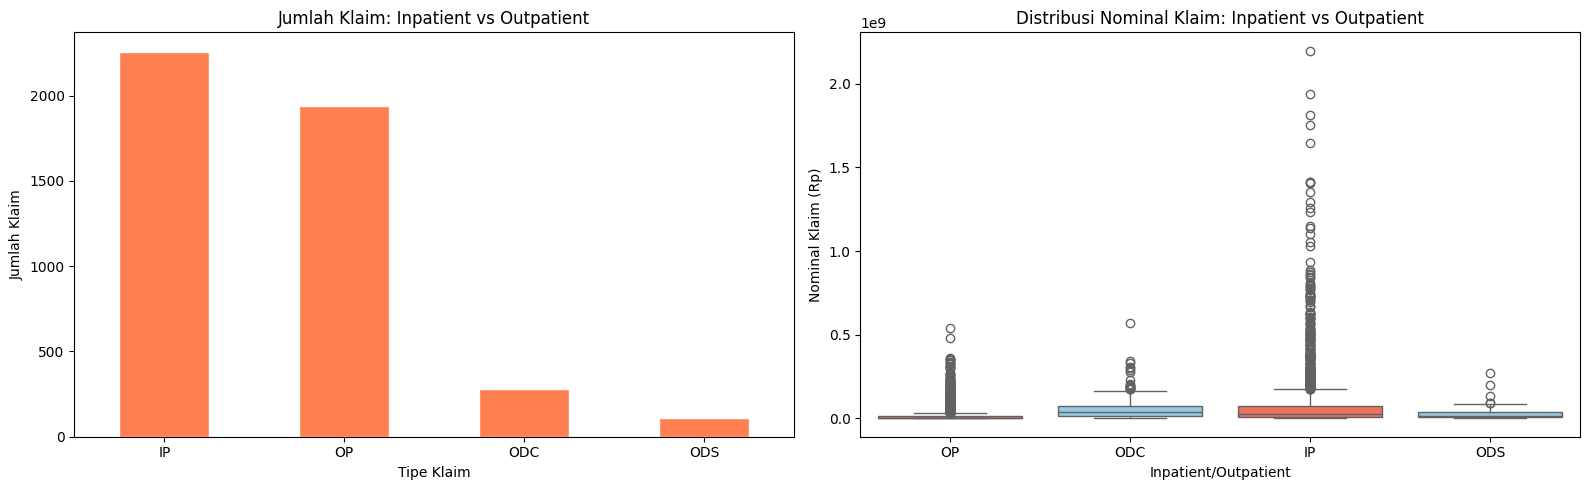

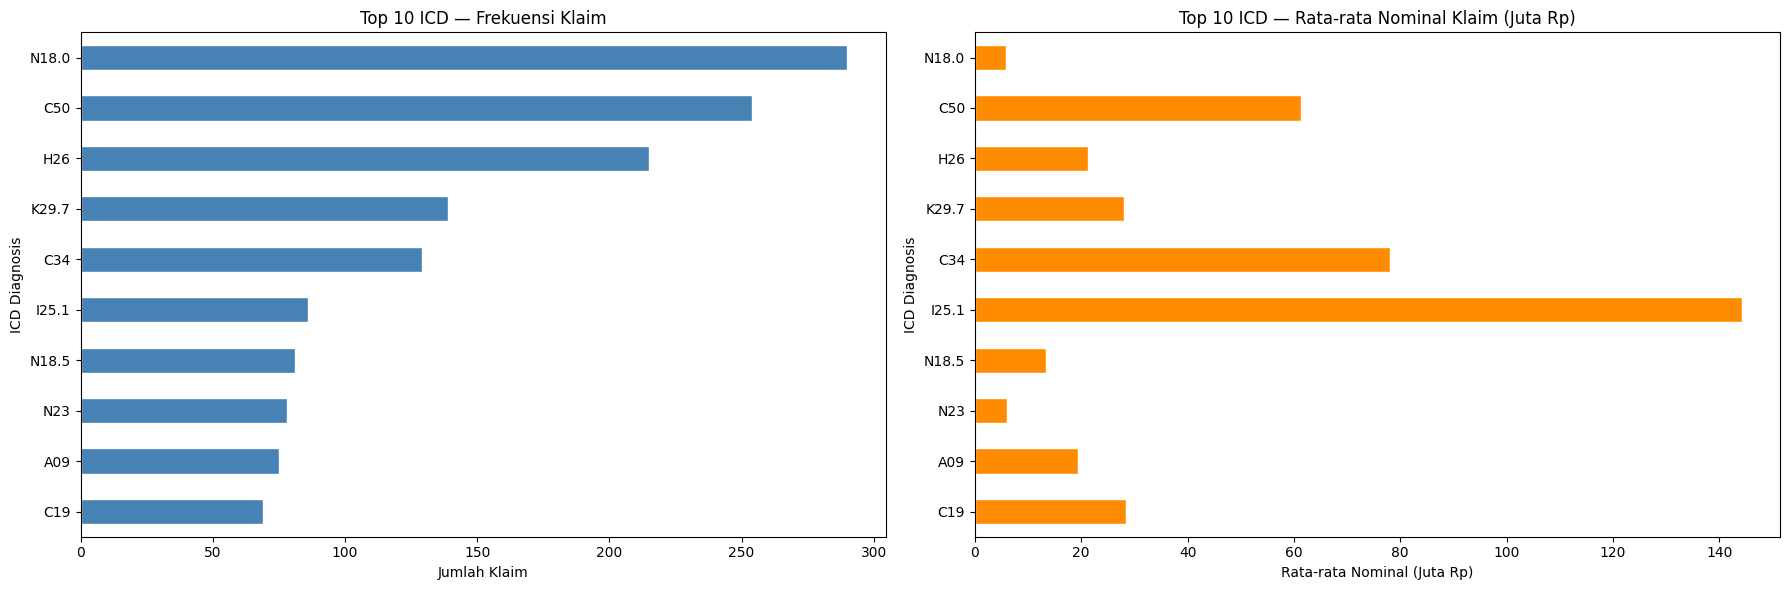

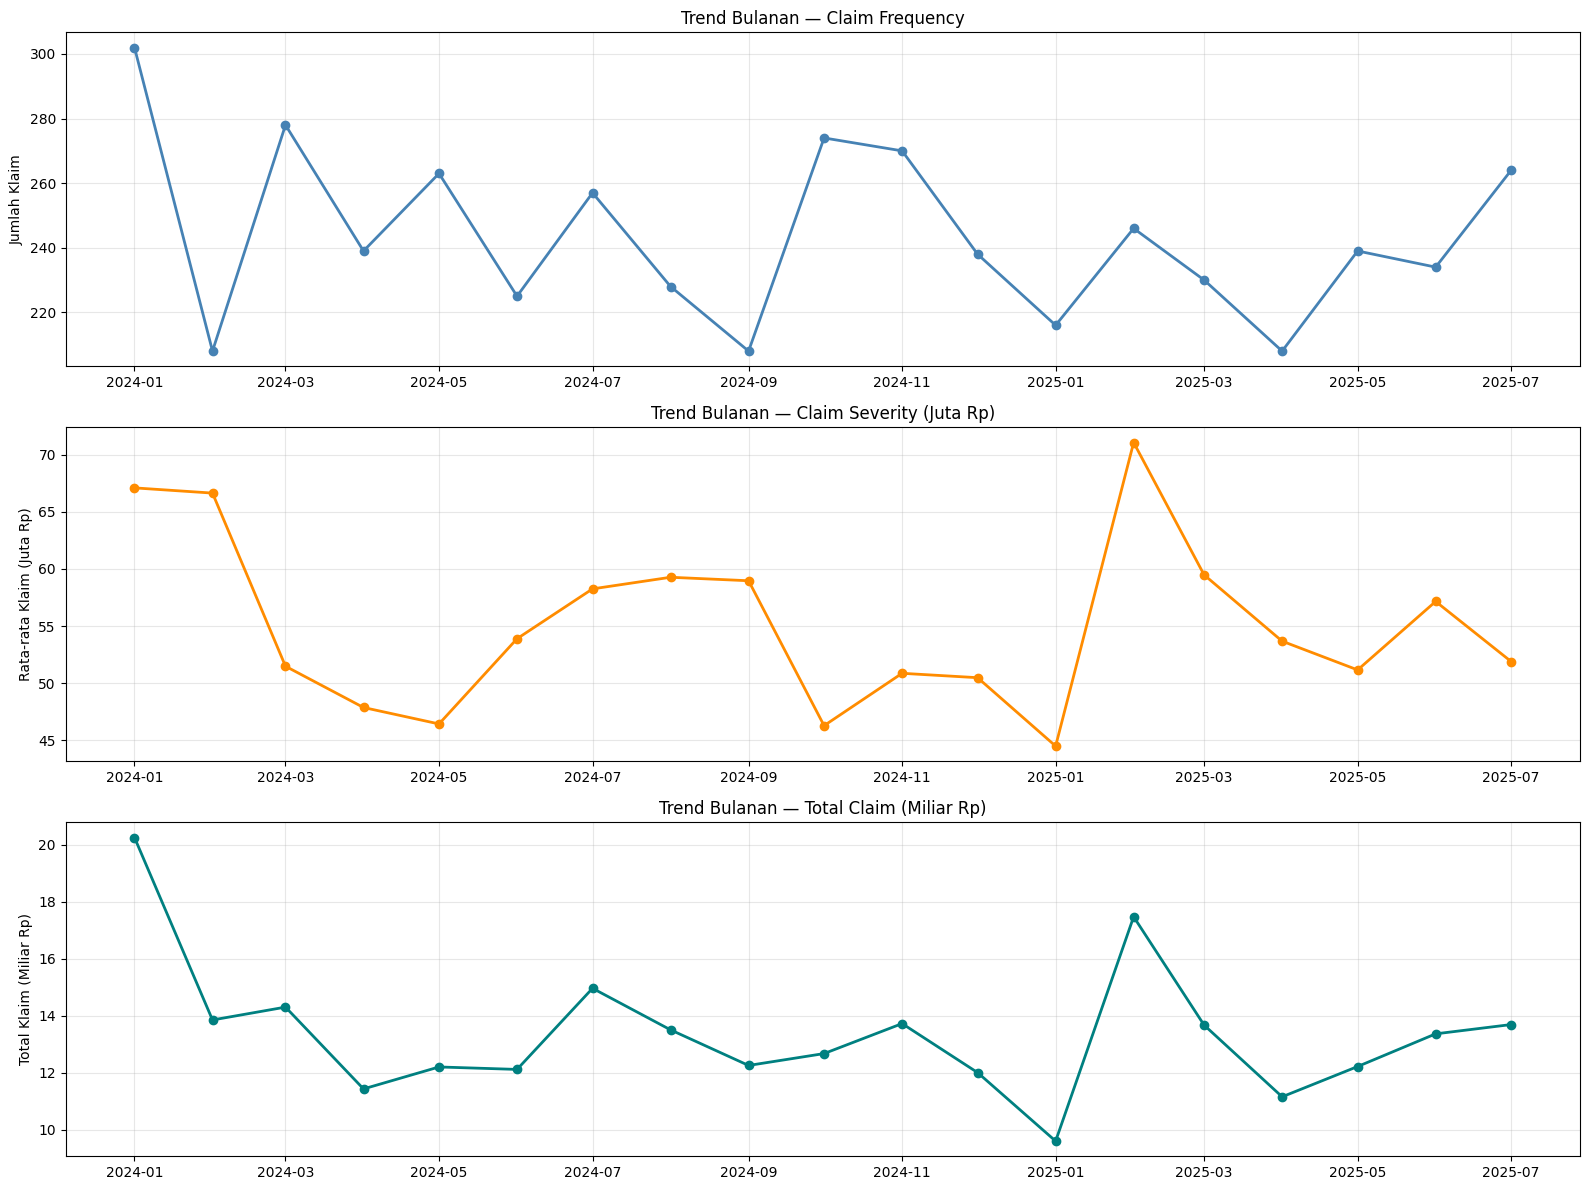

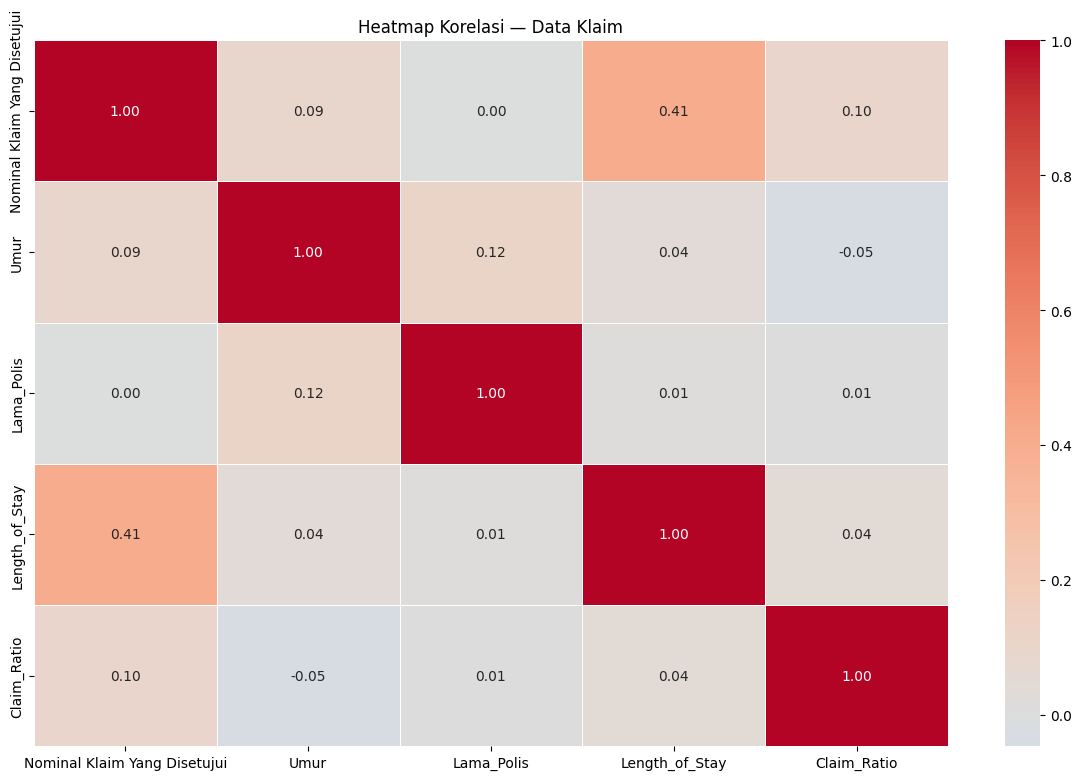


✅ Cell 5 selesai


In [28]:
# ── 1. DISTRIBUSI NOMINAL KLAIM ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(
    df_merged['Nominal Klaim Yang Disetujui'] / 1e6,
    bins=50, color='steelblue', edgecolor='white'
)
axes[0].set_title('Distribusi Nominal Klaim Disetujui (Juta Rp)')
axes[0].set_xlabel('Nominal (Juta Rp)')
axes[0].set_ylabel('Frekuensi')

axes[1].hist(
    np.log1p(df_merged['Nominal Klaim Yang Disetujui']),
    bins=50, color='darkorange', edgecolor='white'
)
axes[1].set_title('Distribusi Log Nominal Klaim Disetujui')
axes[1].set_xlabel('Log(Nominal + 1)')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

# ── 2. KLAIM PER GENDER ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_merged['Gender'].value_counts().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'salmon'],
    edgecolor='white'
)
axes[0].set_title('Jumlah Klaim per Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Jumlah Klaim')
axes[0].tick_params(axis='x', rotation=0)

sns.boxplot(
    data=df_merged,
    x='Gender',
    y='Nominal Klaim Yang Disetujui',
    ax=axes[1],
    palette=['steelblue', 'salmon']
)
axes[1].set_title('Distribusi Nominal Klaim per Gender')
axes[1].set_ylabel('Nominal Klaim (Rp)')

plt.tight_layout()
plt.show()

# ── 3. KLAIM PER KELOMPOK UMUR ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_merged['Kelompok_Umur'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='teal', edgecolor='white'
)
axes[0].set_title('Jumlah Klaim per Kelompok Umur')
axes[0].set_xlabel('Kelompok Umur')
axes[0].set_ylabel('Jumlah Klaim')
axes[0].tick_params(axis='x', rotation=0)

sns.boxplot(
    data=df_merged,
    x='Kelompok_Umur',
    y='Nominal Klaim Yang Disetujui',
    ax=axes[1],
    palette='coolwarm',
    order=['<18', '18-30', '31-45', '46-60', '>60']
)
axes[1].set_title('Distribusi Nominal Klaim per Kelompok Umur')
axes[1].set_ylabel('Nominal Klaim (Rp)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# ── 4. KLAIM PER PLAN CODE ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_merged['Plan Code'].value_counts().plot(
    kind='bar', ax=axes[0], color='mediumpurple', edgecolor='white'
)
axes[0].set_title('Jumlah Klaim per Plan Code')
axes[0].set_xlabel('Plan Code')
axes[0].set_ylabel('Jumlah Klaim')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(
    data=df_merged,
    x='Plan Code',
    y='Nominal Klaim Yang Disetujui',
    ax=axes[1],
    palette='Set2'
)
axes[1].set_title('Distribusi Nominal Klaim per Plan Code')
axes[1].set_ylabel('Nominal Klaim (Rp)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ── 5. KLAIM PER INPATIENT/OUTPATIENT ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_merged['Inpatient/Outpatient'].value_counts().plot(
    kind='bar', ax=axes[0], color='coral', edgecolor='white'
)
axes[0].set_title('Jumlah Klaim: Inpatient vs Outpatient')
axes[0].set_xlabel('Tipe Klaim')
axes[0].set_ylabel('Jumlah Klaim')
axes[0].tick_params(axis='x', rotation=0)

sns.boxplot(
    data=df_merged,
    x='Inpatient/Outpatient',
    y='Nominal Klaim Yang Disetujui',
    ax=axes[1],
    palette=['tomato', 'skyblue']
)
axes[1].set_title('Distribusi Nominal Klaim: Inpatient vs Outpatient')
axes[1].set_ylabel('Nominal Klaim (Rp)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# ── 6. TOP 10 ICD DIAGNOSIS ────────────────────────────
top_icd = (
    df_merged.groupby('ICD Diagnosis')['Nominal Klaim Yang Disetujui']
    .agg(['count', 'mean'])
    .sort_values('count', ascending=False)
    .head(10)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top_icd['count'].plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Top 10 ICD — Frekuensi Klaim')
axes[0].set_xlabel('Jumlah Klaim')
axes[0].invert_yaxis()

top_icd['mean'].div(1e6).plot(
    kind='barh', ax=axes[1], color='darkorange', edgecolor='white'
)
axes[1].set_title('Top 10 ICD — Rata-rata Nominal Klaim (Juta Rp)')
axes[1].set_xlabel('Rata-rata Nominal (Juta Rp)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# ── 7. TREND BULANAN KLAIM ─────────────────────────────
df_merged['Periode_Klaim'] = df_merged['Tanggal Pasien Masuk RS'].dt.to_period('M').dt.to_timestamp()

monthly_trend = df_merged.groupby('Periode_Klaim').agg(
    Claim_Frequency=('Claim ID', 'count'),
    Total_Claim=('Nominal Klaim Yang Disetujui', 'sum')
).reset_index()
monthly_trend['Claim_Severity'] = (
    monthly_trend['Total_Claim'] / monthly_trend['Claim_Frequency']
)

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

axes[0].plot(monthly_trend['Periode_Klaim'], monthly_trend['Claim_Frequency'],
             marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Trend Bulanan — Claim Frequency')
axes[0].set_ylabel('Jumlah Klaim')
axes[0].grid(True, alpha=0.3)

axes[1].plot(monthly_trend['Periode_Klaim'], monthly_trend['Claim_Severity'] / 1e6,
             marker='o', color='darkorange', linewidth=2)
axes[1].set_title('Trend Bulanan — Claim Severity (Juta Rp)')
axes[1].set_ylabel('Rata-rata Klaim (Juta Rp)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(monthly_trend['Periode_Klaim'], monthly_trend['Total_Claim'] / 1e9,
             marker='o', color='teal', linewidth=2)
axes[2].set_title('Trend Bulanan — Total Claim (Miliar Rp)')
axes[2].set_ylabel('Total Klaim (Miliar Rp)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── 8. HEATMAP KORELASI ────────────────────────────────
numeric_cols = df_merged.select_dtypes(include=[np.number]).drop(
    columns=['Nominal Biaya RS Yang Terjadi'], errors='ignore'
)

plt.figure(figsize=(12, 8))
sns.heatmap(
    numeric_cols.corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5
)
plt.title('Heatmap Korelasi — Data Klaim')
plt.tight_layout()
plt.show()

print("\n✅ Cell 5 selesai")

DATA BULANAN


,Periode_Klaim,Claim_Frequency,Total_Claim,Claim_Severity,Time_Index
0,2024-01-01,302,2.026098e+10,6.708934e+07,0
1,2024-02-01,208,1.385965e+10,6.663291e+07,1
2,2024-03-01,278,1.431126e+10,5.147935e+07,2
3,2024-04-01,239,1.144106e+10,4.787056e+07,3
4,2024-05-01,263,1.221146e+10,4.643141e+07,4
5,2024-06-01,225,1.212517e+10,5.388963e+07,5
6,2024-07-01,257,1.497052e+10,5.825104e+07,6
7,2024-08-01,228,1.351294e+10,5.926726e+07,7
8,2024-09-01,208,1.226412e+10,5.896211e+07,8
9,2024-10-01,274,1.268117e+10,4.628163e+07,9



Rentang: 2024-01-01 00:00:00 → 2025-07-01 00:00:00
Total Observasi: 19 bulan

✅ Winsorize severity selesai

FEATURE ENGINEERING SELESAI
Total fitur: 29 kolom


,Periode_Klaim,Claim_Frequency,Total_Claim,Claim_Severity,Time_Index,Month,Quarter,Month_Sin,Month_Cos,Freq_Lag_1,...,Total_Rolling_3,Freq_Rolling_6,Sev_Rolling_6,Total_Rolling_6,Freq_Std_3,Sev_Std_3,Freq_YoY,Sev_YoY,Freq_Growth,Sev_Growth
0,2024-01-01,302,2.026098e+10,6.708934e+07,0,1,1,5.000000e-01,8.660254e-01,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-02-01,208,1.385965e+10,6.663291e+07,1,2,1,8.660254e-01,5.000000e-01,302.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.311258,-0.006803
2,2024-03-01,278,1.431126e+10,5.147935e+07,2,3,1,1.000000e+00,6.123234e-17,208.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.336538,-0.227419
3,2024-04-01,239,1.144106e+10,4.787056e+07,3,4,2,8.660254e-01,-5.000000e-01,278.0,...,1.614396e+10,NaN,NaN,NaN,48.839874,8.883607e+06,NaN,NaN,-0.140288,-0.070102
4,2024-05-01,263,1.221146e+10,4.643141e+07,4,5,2,5.000000e-01,-8.660254e-01,239.0,...,1.320399e+10,NaN,NaN,NaN,35.076108,9.955567e+06,NaN,NaN,0.100418,-0.030063
5,2024-06-01,225,1.212517e+10,5.388963e+07,5,6,2,1.224647e-16,-1.000000e+00,263.0,...,1.265459e+10,NaN,NaN,NaN,19.672316,2.600516e+06,NaN,NaN,-0.144487,0.160629
6,2024-07-01,257,1.497052e+10,5.825104e+07,6,7,3,-5.000000e-01,-8.660254e-01,225.0,...,1.192590e+10,252.500000,5.556553e+07,1.403493e+10,19.218047,3.956544e+06,NaN,NaN,0.142222,0.080932
7,2024-08-01,228,1.351294e+10,5.926726e+07,7,8,3,-8.660254e-01,-5.000000e-01,257.0,...,1.310238e+10,245.000000,5.409248e+07,1.315319e+10,20.428738,5.977045e+06,NaN,NaN,-0.112840,0.017446
8,2024-09-01,208,1.226412e+10,5.896211e+07,8,9,3,-1.000000e+00,-1.836970e-16,228.0,...,1.353621e+10,248.333333,5.286487e+07,1.309540e+10,17.672955,2.856965e+06,NaN,NaN,-0.087719,-0.005149
9,2024-10-01,274,1.268117e+10,4.628163e+07,9,10,4,-8.660254e-01,5.000000e-01,208.0,...,1.358252e+10,236.666667,5.411200e+07,1.275421e+10,24.637370,5.214491e+05,NaN,NaN,0.317308,-0.215062



Korelasi terhadap Claim_Frequency:
Freq_Growth      0.809046
Total_Claim      0.608452
Sev_Lag_3        0.414431
Freq_Std_3       0.364812
Sev_Rolling_6    0.336311
Sev_YoY          0.188419
Month_Cos        0.161857
Quarter          0.129065
Freq_Lag_2       0.127299
Total_Lag_2      0.116185
Name: Claim_Frequency, dtype: float64

Korelasi terhadap Claim_Severity:
Total_Claim       0.751834
Sev_Growth        0.637121
Total_Lag_1       0.283169
Sev_Lag_1         0.197673
Sev_YoY           0.167045
Month_Cos         0.149219
Month_Sin         0.148773
Freq_Lag_1        0.113689
Freq_Rolling_6    0.095179
Freq_Lag_3        0.046100
Name: Claim_Severity, dtype: float64

Korelasi terhadap Total_Claim:
Claim_Severity     0.751834
Claim_Frequency    0.608452
Sev_Growth         0.594911
Freq_Growth        0.356921
Sev_YoY            0.241707
Month_Cos          0.235529
Month_Sin          0.081851
Sev_Lag_1          0.040699
Freq_Lag_3        -0.039440
Total_Lag_1       -0.048243
Name: Total_

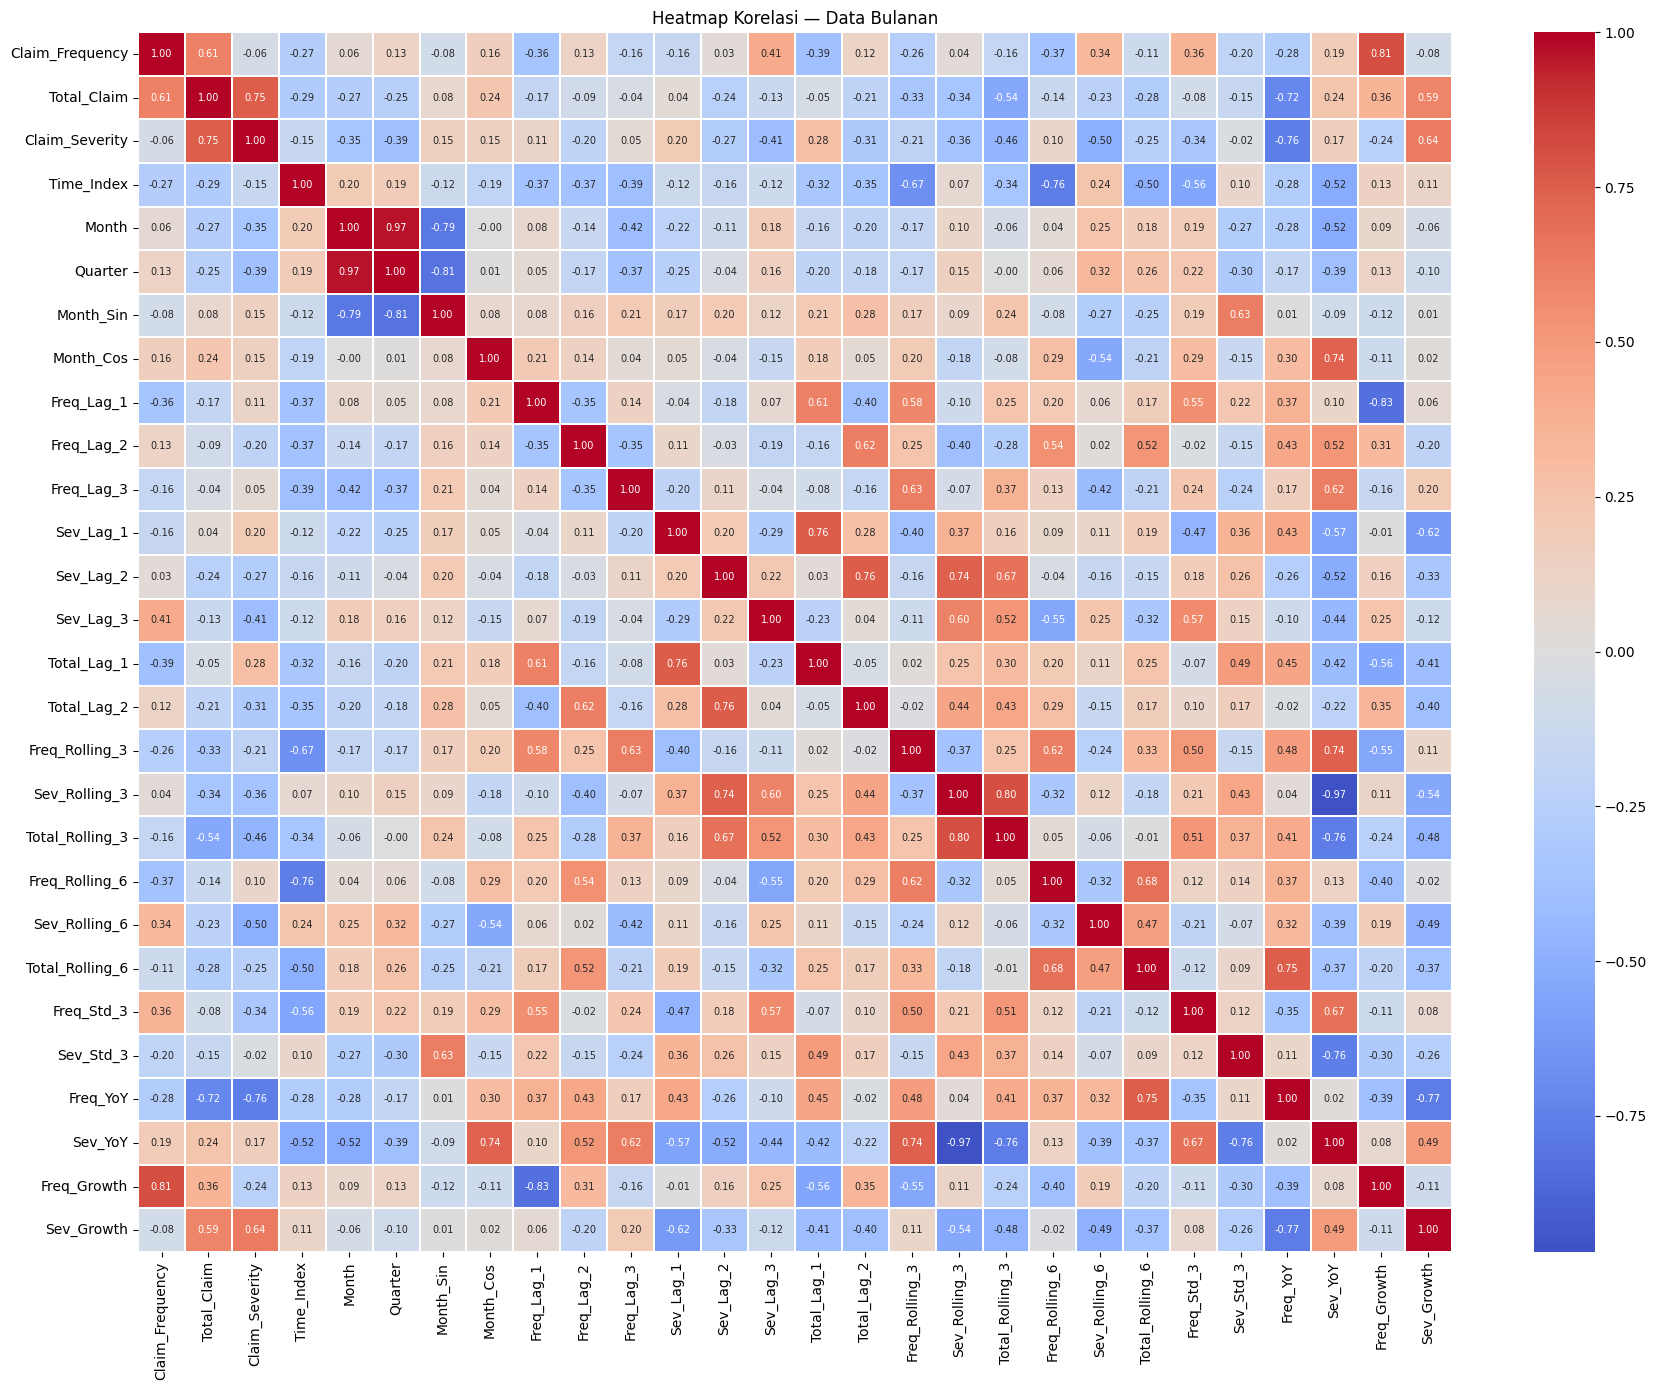


✅ Cell 6 selesai


In [29]:
# ── AGGREGASI BULANAN ──────────────────────────────────
df_monthly = df_merged.groupby('Periode_Klaim').agg(
    Claim_Frequency=('Claim ID', 'count'),
    Total_Claim=('Nominal Klaim Yang Disetujui', 'sum')
).reset_index()

df_monthly['Claim_Severity'] = (
    df_monthly['Total_Claim'] / df_monthly['Claim_Frequency']
)

# Sort dan reset index
df_monthly = df_monthly.sort_values('Periode_Klaim').reset_index(drop=True)
df_monthly['Time_Index'] = np.arange(len(df_monthly))

print("=" * 50)
print("DATA BULANAN")
print("=" * 50)
display(df_monthly)
print(f"\nRentang: {df_monthly['Periode_Klaim'].min()} → {df_monthly['Periode_Klaim'].max()}")
print(f"Total Observasi: {len(df_monthly)} bulan")

# ── WINSORIZE SEVERITY ─────────────────────────────────
# Handle outlier di level bulanan
df_monthly['Claim_Severity'] = winsorize(
    df_monthly['Claim_Severity'], limits=[0.05, 0.05]
)
df_monthly['Total_Claim'] = (
    df_monthly['Claim_Frequency'] * df_monthly['Claim_Severity']
)

print("\n✅ Winsorize severity selesai")

# ── FEATURE ENGINEERING ────────────────────────────────

# Kalendar features — tangkap seasonality
df_monthly['Month']   = df_monthly['Periode_Klaim'].dt.month
df_monthly['Quarter'] = df_monthly['Periode_Klaim'].dt.quarter

# Sin/Cos encoding untuk month (cyclical)
df_monthly['Month_Sin'] = np.sin(2 * np.pi * df_monthly['Month'] / 12)
df_monthly['Month_Cos'] = np.cos(2 * np.pi * df_monthly['Month'] / 12)

# Lag features — Frequency
df_monthly['Freq_Lag_1'] = df_monthly['Claim_Frequency'].shift(1)
df_monthly['Freq_Lag_2'] = df_monthly['Claim_Frequency'].shift(2)
df_monthly['Freq_Lag_3'] = df_monthly['Claim_Frequency'].shift(3)

# Lag features — Severity
df_monthly['Sev_Lag_1'] = df_monthly['Claim_Severity'].shift(1)
df_monthly['Sev_Lag_2'] = df_monthly['Claim_Severity'].shift(2)
df_monthly['Sev_Lag_3'] = df_monthly['Claim_Severity'].shift(3)

# Lag features — Total
df_monthly['Total_Lag_1'] = df_monthly['Total_Claim'].shift(1)
df_monthly['Total_Lag_2'] = df_monthly['Total_Claim'].shift(2)

# Rolling mean — window 3
df_monthly['Freq_Rolling_3']  = df_monthly['Claim_Frequency'].shift(1).rolling(3).mean()
df_monthly['Sev_Rolling_3']   = df_monthly['Claim_Severity'].shift(1).rolling(3).mean()
df_monthly['Total_Rolling_3'] = df_monthly['Total_Claim'].shift(1).rolling(3).mean()

# Rolling mean — window 6
df_monthly['Freq_Rolling_6']  = df_monthly['Claim_Frequency'].shift(1).rolling(6).mean()
df_monthly['Sev_Rolling_6']   = df_monthly['Claim_Severity'].shift(1).rolling(6).mean()
df_monthly['Total_Rolling_6'] = df_monthly['Total_Claim'].shift(1).rolling(6).mean()

# Rolling std — window 3 (volatilitas)
df_monthly['Freq_Std_3'] = df_monthly['Claim_Frequency'].shift(1).rolling(3).std()
df_monthly['Sev_Std_3']  = df_monthly['Claim_Severity'].shift(1).rolling(3).std()

# YoY features — bulan yang sama tahun lalu (shift 12)
df_monthly['Freq_YoY'] = df_monthly['Claim_Frequency'].shift(12)
df_monthly['Sev_YoY']  = df_monthly['Claim_Severity'].shift(12)

# Growth rate bulan sebelumnya
df_monthly['Freq_Growth'] = (
    df_monthly['Claim_Frequency'] / df_monthly['Freq_Lag_1'] - 1
).replace([np.inf, -np.inf], 0)

df_monthly['Sev_Growth'] = (
    df_monthly['Claim_Severity'] / df_monthly['Sev_Lag_1'] - 1
).replace([np.inf, -np.inf], 0)

print("\n" + "=" * 50)
print("FEATURE ENGINEERING SELESAI")
print("=" * 50)
print(f"Total fitur: {df_monthly.shape[1]} kolom")
display(df_monthly.head(10))

# ── PEARSON CORRELATION ────────────────────────────────
numeric_monthly = df_monthly.select_dtypes(include=[np.number])
corr_matrix = numeric_monthly.corr(method='pearson')

# Korelasi ke masing-masing target
for target in ['Claim_Frequency', 'Claim_Severity', 'Total_Claim']:
    print(f"\nKorelasi terhadap {target}:")
    print(
        corr_matrix[target]
        .drop([target], errors='ignore')
        .sort_values(ascending=False)
        .head(10)
    )

# Heatmap korelasi monthly
plt.figure(figsize=(18, 14))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.3, annot_kws={'size': 7}
)
plt.title('Heatmap Korelasi — Data Bulanan')
plt.tight_layout()
plt.show()

print("\n✅ Cell 6 selesai")

In [30]:
# ── FITUR EKSOGEN DARI DATA POLIS PER BULAN ───────────
# Hitung distribusi peserta aktif per bulan
# Peserta aktif = polis yang sudah efektif di bulan tersebut

all_periods = df_monthly['Periode_Klaim'].tolist()

exog_rows = []
for period in all_periods:
    # Polis aktif = tanggal efektif <= periode tersebut
    active = df_polis[df_polis['Tanggal Efektif Polis'] <= period]

    # Hitung fitur portfolio bulan tersebut
    n_active     = len(active)
    pct_female   = (active['Gender'] == 'F').mean() if n_active > 0 else 0
    avg_umur     = active['Umur'].mean() if n_active > 0 else 0
    pct_old      = (active['Umur'] >= 46).mean() if n_active > 0 else 0
    pct_m001     = (active['Plan Code'] == 'M-001').mean() if n_active > 0 else 0
    pct_m003     = (active['Plan Code'] == 'M-003').mean() if n_active > 0 else 0
    avg_lama     = active['Lama_Polis'].mean() if n_active > 0 else 0

    exog_rows.append({
        'Periode_Klaim' : period,
        'N_Active'      : n_active,
        'Pct_Female'    : pct_female,
        'Avg_Umur'      : avg_umur,
        'Pct_Old'       : pct_old,
        'Pct_M001'      : pct_m001,
        'Pct_M003'      : pct_m003,
        'Avg_Lama_Polis': avg_lama,
    })

df_exog = pd.DataFrame(exog_rows)

print("=" * 50)
print("FITUR EKSOGEN PORTFOLIO PER BULAN")
print("=" * 50)
display(df_exog)

# ── MERGE KE df_monthly ────────────────────────────────
df_monthly = df_monthly.merge(df_exog, on='Periode_Klaim', how='left')

# ── FITUR TAMBAHAN ─────────────────────────────────────

# Claim rate = frequency / n_active (rasio klaim per peserta)
df_monthly['Claim_Rate'] = (
    df_monthly['Claim_Frequency'] / df_monthly['N_Active']
).replace([np.inf, -np.inf], 0)

# Lag claim rate
df_monthly['ClaimRate_Lag_1'] = df_monthly['Claim_Rate'].shift(1)
df_monthly['ClaimRate_Lag_2'] = df_monthly['Claim_Rate'].shift(2)

# Trend linear per target (detrended residual)
from numpy.polynomial import polynomial as P

for col in ['Claim_Frequency', 'Claim_Severity', 'Total_Claim']:
    x    = np.arange(len(df_monthly))
    y    = df_monthly[col].values
    coef = np.polyfit(x, y, deg=1)
    trend = np.polyval(coef, x)
    df_monthly[f'{col}_Detrend'] = y - trend

# Interaction feature: umur tua × severity lag
df_monthly['Old_x_SevLag1'] = (
    df_monthly['Pct_Old'] * df_monthly['Sev_Lag_1']
)

# Interaction: pct_female × freq_lag1
df_monthly['Female_x_FreqLag1'] = (
    df_monthly['Pct_Female'] * df_monthly['Freq_Lag_1']
)

print("\n✅ Fitur eksogen & tambahan selesai")
print(f"Total kolom df_monthly: {df_monthly.shape[1]}")

# ── UPDATE FEATURE LIST ────────────────────────────────
features = [
    'Time_Index',
    'Month_Sin', 'Month_Cos',
    'Quarter',
    'Freq_Lag_1', 'Freq_Lag_2', 'Freq_Lag_3',
    'Sev_Lag_1',  'Sev_Lag_2',  'Sev_Lag_3',
    'Total_Lag_1', 'Total_Lag_2',
    'Freq_Rolling_3', 'Sev_Rolling_3', 'Total_Rolling_3',
    'Freq_Rolling_6', 'Sev_Rolling_6', 'Total_Rolling_6',
    'Freq_Std_3', 'Sev_Std_3',
    'Freq_YoY', 'Sev_YoY',
    # Eksogen portfolio
    'N_Active', 'Pct_Female', 'Avg_Umur',
    'Pct_Old', 'Pct_M001', 'Pct_M003', 'Avg_Lama_Polis',
    # Claim rate
    'Claim_Rate', 'ClaimRate_Lag_1', 'ClaimRate_Lag_2',
    # Detrend
    'Claim_Frequency_Detrend', 'Claim_Severity_Detrend', 'Total_Claim_Detrend',
    # Interaction
    'Old_x_SevLag1', 'Female_x_FreqLag1',
]

print(f"\nTotal fitur: {len(features)}")
print("\n✅ Cell 6B selesai — jalankan Cell 7, 8, Tuning, 9, 10")

FITUR EKSOGEN PORTFOLIO PER BULAN


,Periode_Klaim,N_Active,Pct_Female,Avg_Umur,Pct_Old,Pct_M001,Pct_M003,Avg_Lama_Polis
0,2024-01-01,4096,0.488037,52.32251,0.696533,0.13916,0.310791,10.377915
1,2024-02-01,4096,0.488037,52.32251,0.696533,0.13916,0.310791,10.377915
2,2024-03-01,4096,0.488037,52.32251,0.696533,0.13916,0.310791,10.377915
3,2024-04-01,4096,0.488037,52.32251,0.696533,0.13916,0.310791,10.377915
4,2024-05-01,4096,0.488037,52.32251,0.696533,0.13916,0.310791,10.377915
5,2024-06-01,4096,0.488037,52.32251,0.696533,0.13916,0.310791,10.377915
6,2024-07-01,4096,0.488037,52.32251,0.696533,0.13916,0.310791,10.377915
7,2024-08-01,4096,0.488037,52.32251,0.696533,0.13916,0.310791,10.377915
8,2024-09-01,4096,0.488037,52.32251,0.696533,0.13916,0.310791,10.377915
9,2024-10-01,4096,0.488037,52.32251,0.696533,0.13916,0.310791,10.377915



✅ Fitur eksogen & tambahan selesai
Total kolom df_monthly: 44

Total fitur: 37

✅ Cell 6B selesai — jalankan Cell 7, 8, Tuning, 9, 10



ADF Test — Claim Frequency
  ADF Statistic : -2.7778
  p-value       : 0.0615
  Critical 1%   : -3.8893
  Critical 5%   : -3.0544
  ⚠️  TIDAK STASIONER (gagal tolak H0)

ADF Test — Claim Severity
  ADF Statistic : -3.6032
  p-value       : 0.0057
  Critical 1%   : -3.8591
  Critical 5%   : -3.0420
  ✅ STASIONER (tolak H0)

ADF Test — Total Claim
  ADF Statistic : -2.4607
  p-value       : 0.1253
  Critical 1%   : -4.0689
  Critical 5%   : -3.1271
  ⚠️  TIDAK STASIONER (gagal tolak H0)


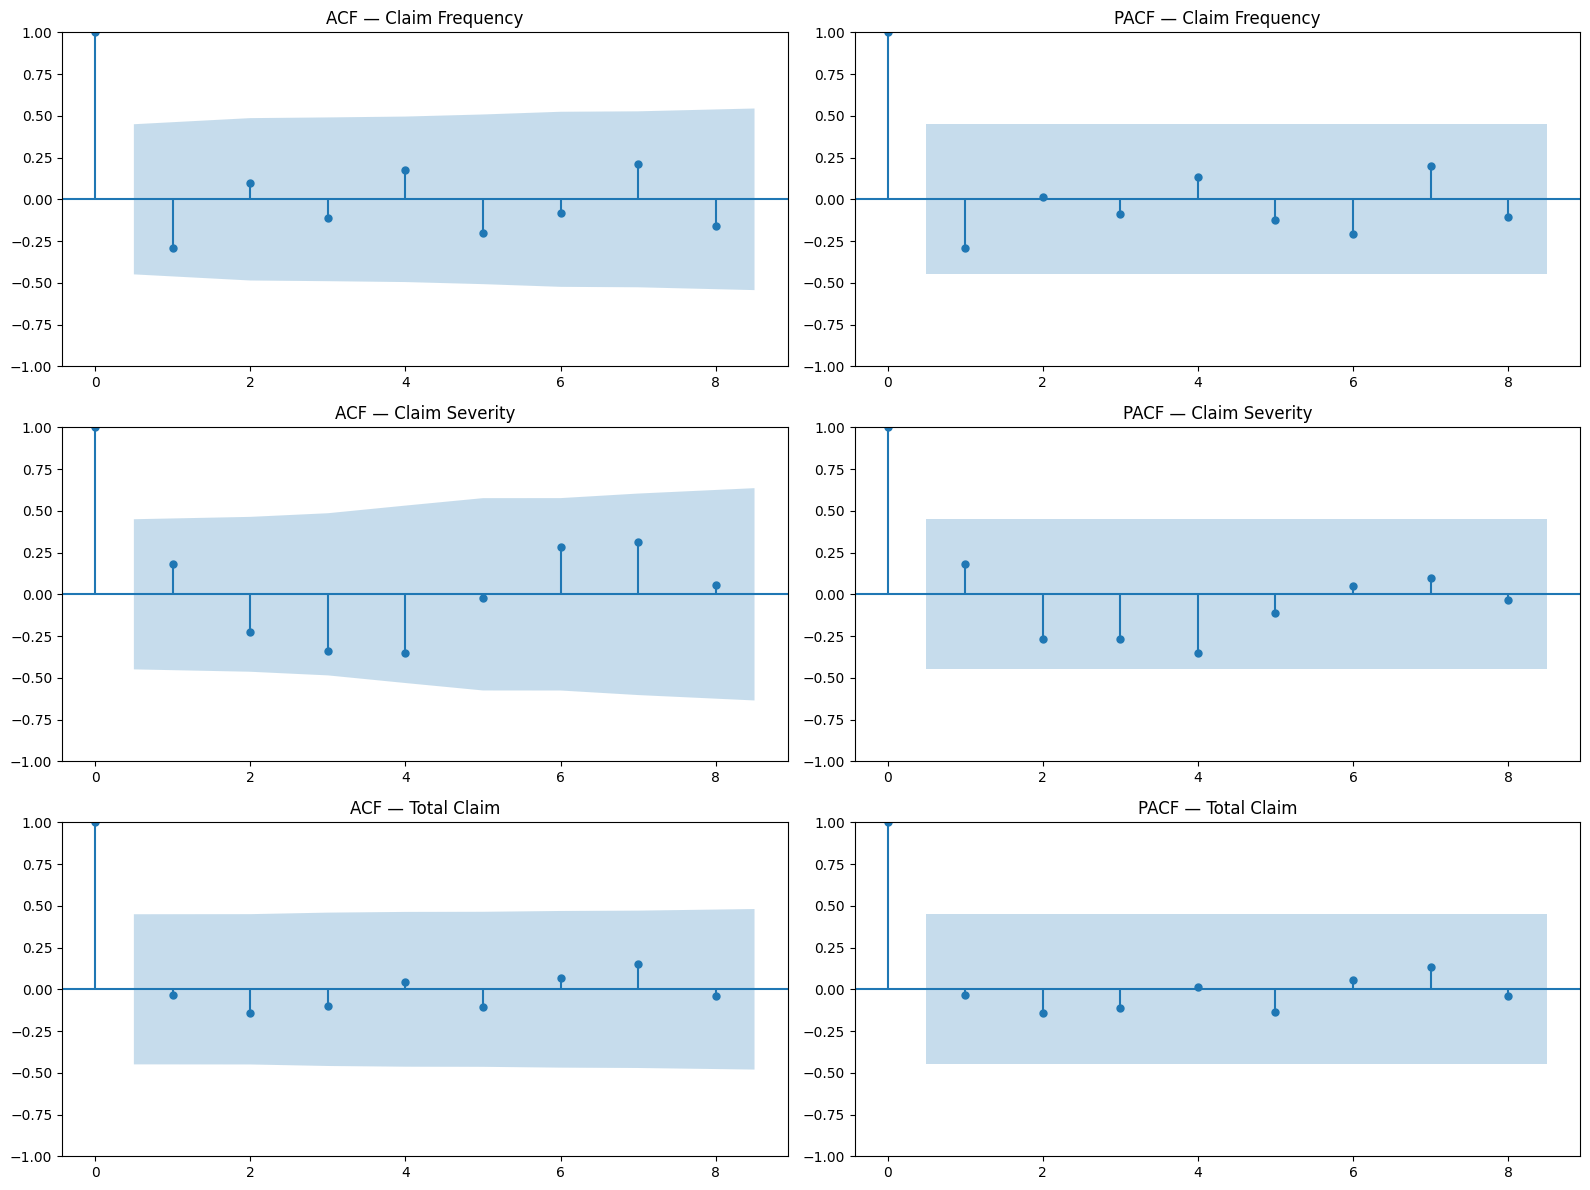


SARIMAX — Claim Frequency
  AIC : 54.09
  BIC : 52.13
  In-sample MAPE: 21.22%

SARIMAX — Claim Severity
  AIC : 178.77
  BIC : 176.81
  In-sample MAPE: 24.54%

SARIMAX — Total Claim
  AIC : 235.05
  BIC : 233.09
  In-sample MAPE: 52.53%

SARIMAX FORECAST — Agustus s/d Desember 2025


,Periode,Freq_SARIMAX,Sev_SARIMAX,Total_SARIMAX
0,2025-08-01,261.621037,5.289851e+07,1.331037e+10
1,2025-09-01,246.637644,5.115656e+07,1.266773e+10
2,2025-10-01,266.546521,4.370666e+07,1.296182e+10
3,2025-11-01,258.556452,4.445625e+07,1.361328e+10
4,2025-12-01,239.562660,4.296371e+07,1.270819e+10


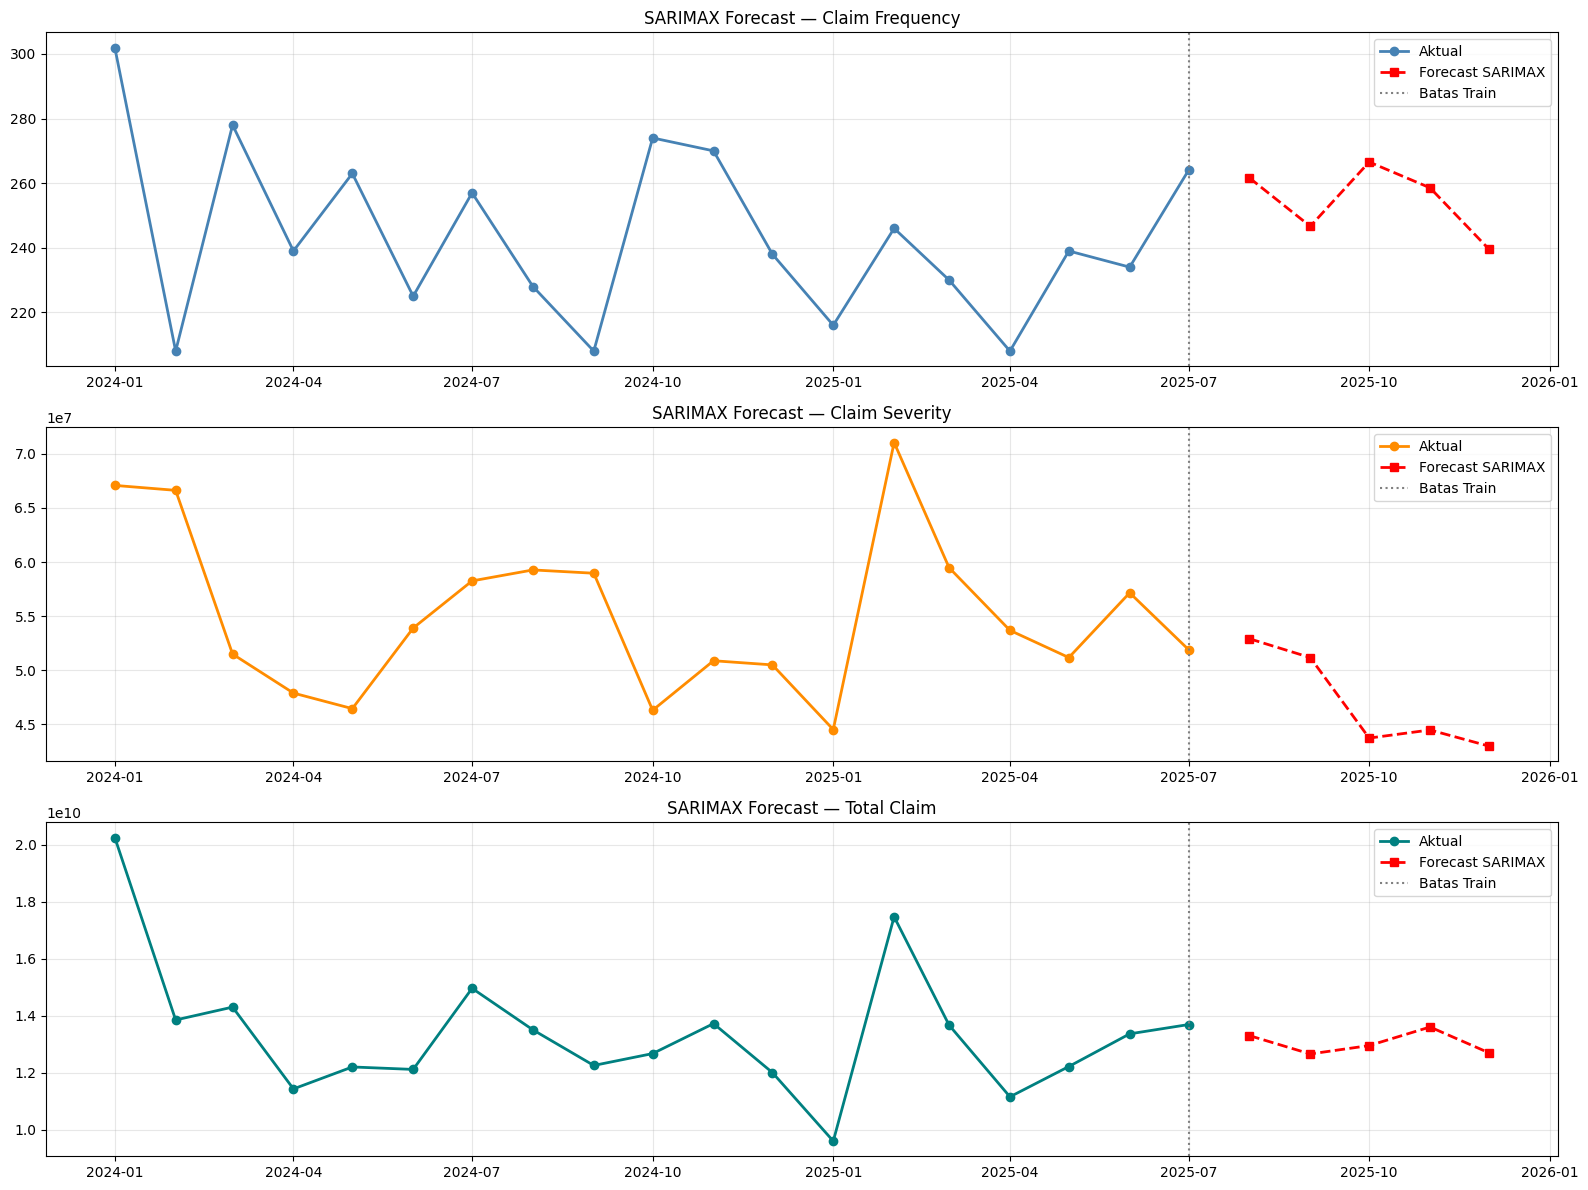


✅ Cell 7 selesai


In [31]:
# ── STATIONARITY CHECK (ADF TEST) ─────────────────────
def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"\n{'='*40}")
    print(f"ADF Test — {name}")
    print(f"{'='*40}")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    print(f"  Critical 1%   : {result[4]['1%']:.4f}")
    print(f"  Critical 5%   : {result[4]['5%']:.4f}")
    if result[1] <= 0.05:
        print("  ✅ STASIONER (tolak H0)")
    else:
        print("  ⚠️  TIDAK STASIONER (gagal tolak H0)")
    return result[1]

p_freq  = adf_test(df_monthly['Claim_Frequency'], 'Claim Frequency')
p_sev   = adf_test(df_monthly['Claim_Severity'],  'Claim Severity')
p_total = adf_test(df_monthly['Total_Claim'],      'Total Claim')

# ── ACF & PACF PLOT ────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

targets = {
    'Claim_Frequency': 'Claim Frequency',
    'Claim_Severity' : 'Claim Severity',
    'Total_Claim'    : 'Total Claim'
}

for i, (col, label) in enumerate(targets.items()):
    n_obs    = df_monthly[col].dropna().shape[0]
    max_lags = min(10, n_obs // 2 - 1)  # max 50% dari sample size

    plot_acf(
        df_monthly[col].dropna(), lags=max_lags,
        ax=axes[i][0], title=f'ACF — {label}'
    )
    plot_pacf(
        df_monthly[col].dropna(), lags=max_lags,
        ax=axes[i][1], title=f'PACF — {label}',
        method='ywm'
    )

plt.tight_layout()
plt.show()

# ── SARIMAX MODEL ──────────────────────────────────────
# Train set: semua data sampai Juli 2025
# Test  set: prediksi Agustus–Desember 2025 (5 bulan)

train_sarimax = df_monthly.copy()

def fit_sarimax(series, name, order=(1,0,1), seasonal_order=(1,0,1,12)):
    print(f"\n{'='*40}")
    print(f"SARIMAX — {name}")
    print(f"{'='*40}")
    try:
        model = SARIMAX(
            series,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        result = model.fit(disp=False)
        print(f"  AIC : {result.aic:.2f}")
        print(f"  BIC : {result.bic:.2f}")

        # In-sample MAPE
        fitted    = result.fittedvalues
        actual    = series
        mask      = actual != 0
        in_mape   = np.mean(np.abs((actual[mask] - fitted[mask]) / actual[mask])) * 100
        print(f"  In-sample MAPE: {in_mape:.2f}%")

        return result
    except Exception as e:
        print(f"  ❌ Error: {e}")
        return None

# Fit SARIMAX untuk masing-masing target
sarimax_freq  = fit_sarimax(
    train_sarimax['Claim_Frequency'],
    'Claim Frequency',
    order=(1,0,1), seasonal_order=(1,0,1,12)
)

sarimax_sev   = fit_sarimax(
    train_sarimax['Claim_Severity'],
    'Claim Severity',
    order=(1,0,1), seasonal_order=(1,0,1,12)
)

sarimax_total = fit_sarimax(
    train_sarimax['Total_Claim'],
    'Total Claim',
    order=(1,0,1), seasonal_order=(1,0,1,12)
)

# ── FORECAST SARIMAX 5 BULAN ───────────────────────────
n_forecast = 5

forecast_freq_sarimax  = sarimax_freq.forecast(steps=n_forecast)
forecast_sev_sarimax   = sarimax_sev.forecast(steps=n_forecast)
forecast_total_sarimax = sarimax_total.forecast(steps=n_forecast)

future_periods = pd.date_range(
    start='2025-08-01', periods=n_forecast, freq='MS'
)

df_forecast_sarimax = pd.DataFrame({
    'Periode'               : future_periods,
    'Freq_SARIMAX'          : forecast_freq_sarimax.values,
    'Sev_SARIMAX'           : forecast_sev_sarimax.values,
    'Total_SARIMAX'         : forecast_total_sarimax.values,
})

print("\n" + "=" * 50)
print("SARIMAX FORECAST — Agustus s/d Desember 2025")
print("=" * 50)
display(df_forecast_sarimax)

# ── PLOT SARIMAX FORECAST ──────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

plot_data = [
    ('Claim_Frequency', 'Freq_SARIMAX',  'Claim Frequency', 'steelblue'),
    ('Claim_Severity',  'Sev_SARIMAX',   'Claim Severity',  'darkorange'),
    ('Total_Claim',     'Total_SARIMAX', 'Total Claim',     'teal'),
]

for i, (actual_col, forecast_col, title, color) in enumerate(plot_data):
    axes[i].plot(
        df_monthly['Periode_Klaim'],
        df_monthly[actual_col],
        marker='o', color=color, linewidth=2, label='Aktual'
    )
    axes[i].plot(
        df_forecast_sarimax['Periode'],
        df_forecast_sarimax[forecast_col],
        marker='s', color='red', linewidth=2,
        linestyle='--', label='Forecast SARIMAX'
    )
    axes[i].axvline(
        x=pd.Timestamp('2025-07-01'),
        color='gray', linestyle=':', linewidth=1.5,
        label='Batas Train'
    )
    axes[i].set_title(f'SARIMAX Forecast — {title}')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Cell 7 selesai")

Data setelah drop NaN: 7 bulan
Range: 2025-01-01 00:00:00 → 2025-07-01 00:00:00

WALK-FORWARD VALIDATION — XGBoost

  Frequency:
    Walk-Forward MAPE : 7.75%
    Walk-Forward RMSE : 18

  Severity:
    Walk-Forward MAPE : 16.54%
    Walk-Forward RMSE : 9,012,715

  Total:
    Walk-Forward MAPE : 20.66%
    Walk-Forward RMSE : 2,535,853,106

TRAINING FINAL XGBoost — Full Data
  ✅ XGB Frequency trained
  ✅ XGB Severity trained
  ✅ XGB Total trained

XGBoost FORECAST — Agustus s/d Desember 2025


,Periode,Freq_XGB,Sev_XGB,Total_XGB
0,2025-08-01,250.526352,51593392.0,1.330659e+10
1,2025-09-01,243.250824,50558224.0,1.194625e+10
2,2025-10-01,244.459152,49631408.0,1.287044e+10
3,2025-11-01,248.278992,58382952.0,1.398180e+10
4,2025-12-01,235.852203,51201888.0,1.360190e+10


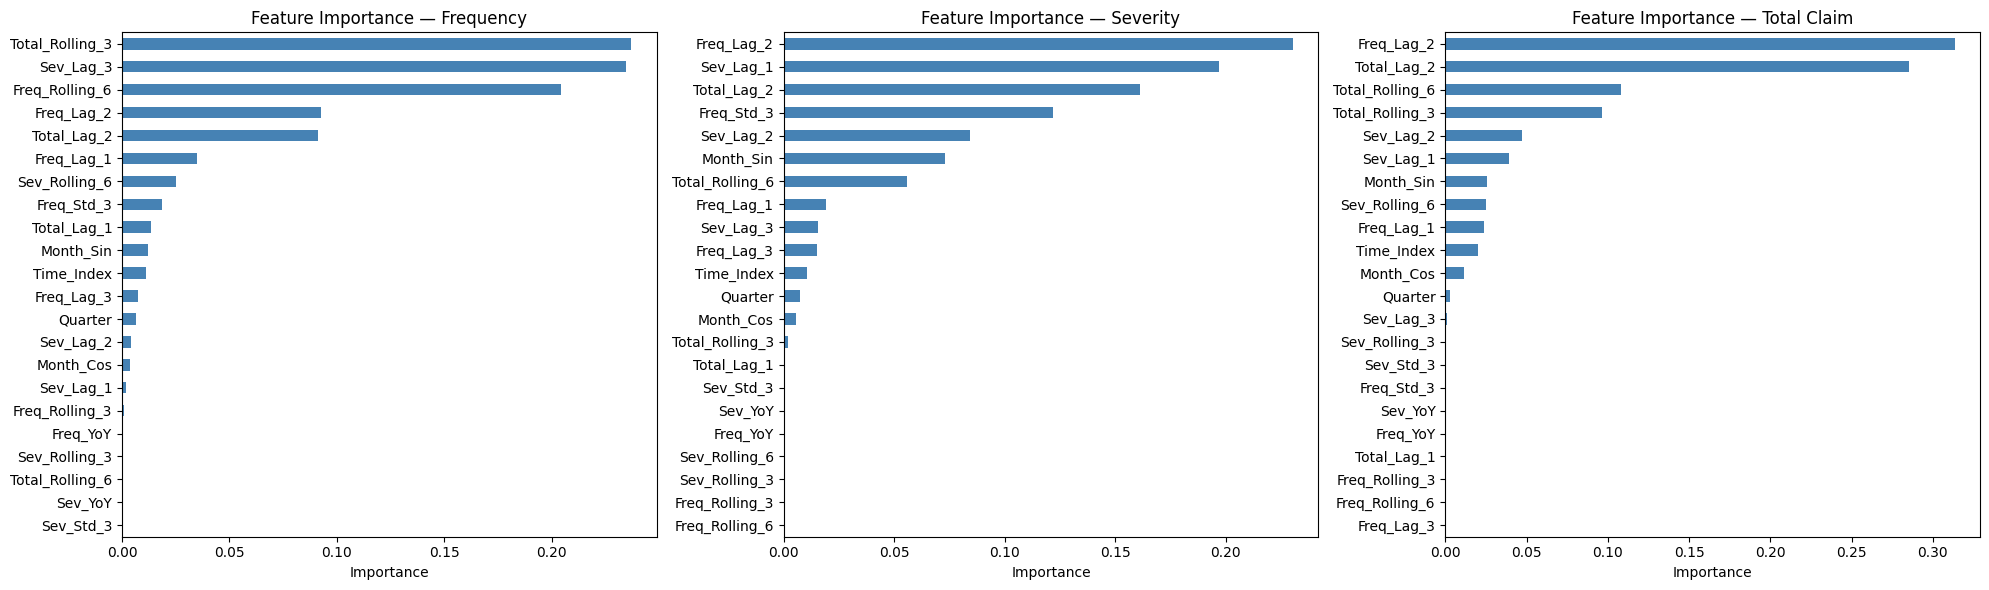


✅ Cell 8 selesai


In [32]:
# ── FEATURE SET ───────────────────────────────────────
features = [
    'Time_Index',
    'Month_Sin', 'Month_Cos',
    'Quarter',
    'Freq_Lag_1', 'Freq_Lag_2', 'Freq_Lag_3',
    'Sev_Lag_1',  'Sev_Lag_2',  'Sev_Lag_3',
    'Total_Lag_1', 'Total_Lag_2',
    'Freq_Rolling_3', 'Sev_Rolling_3', 'Total_Rolling_3',
    'Freq_Rolling_6', 'Sev_Rolling_6', 'Total_Rolling_6',
    'Freq_Std_3', 'Sev_Std_3',
    'Freq_YoY', 'Sev_YoY',
]

targets = {
    'Claim_Frequency' : 'Frequency',
    'Claim_Severity'  : 'Severity',
    'Total_Claim'     : 'Total',
}

# Drop baris dengan NaN di features
df_model = df_monthly.dropna(subset=features).reset_index(drop=True)

print(f"Data setelah drop NaN: {len(df_model)} bulan")
print(f"Range: {df_model['Periode_Klaim'].min()} → {df_model['Periode_Klaim'].max()}")

# ── WALK-FORWARD VALIDATION ────────────────────────────
def walk_forward_validation(df, target_col, features, n_test=5):
    """
    Expanding window walk-forward validation.
    Setiap iterasi: train di t=0..n-i, predict t=n-i+1
    """
    mapes  = []
    rmses  = []
    n      = len(df)

    for i in range(n_test, 0, -1):
        train = df.iloc[:n - i]
        val   = df.iloc[n - i]

        X_train = train[features]
        y_train = train[target_col]
        X_val   = pd.DataFrame([val[features]])
        y_val   = val[target_col]

        model = XGBRegressor(
            n_estimators=200,
            max_depth=2,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            verbosity=0
        )
        model.fit(X_train, y_train)
        pred = model.predict(X_val)[0]
        pred = max(0, pred)

        if y_val != 0:
            mape = abs(y_val - pred) / abs(y_val) * 100
            mapes.append(mape)

        rmse = np.sqrt((y_val - pred) ** 2)
        rmses.append(rmse)

    return np.mean(mapes), np.mean(rmses)

print("\n" + "=" * 50)
print("WALK-FORWARD VALIDATION — XGBoost")
print("=" * 50)

wf_results = {}
for target_col, label in targets.items():
    mape, rmse = walk_forward_validation(
        df_model, target_col, features, n_test=5
    )
    wf_results[target_col] = {'MAPE': mape, 'RMSE': rmse}
    print(f"\n  {label}:")
    print(f"    Walk-Forward MAPE : {mape:.2f}%")
    print(f"    Walk-Forward RMSE : {rmse:,.0f}")

# ── TRAIN FINAL XGBoost (FULL DATA) ───────────────────
print("\n" + "=" * 50)
print("TRAINING FINAL XGBoost — Full Data")
print("=" * 50)

xgb_params = dict(
    n_estimators=200,
    max_depth=2,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)

X_full = df_model[features]

# Frequency
xgb_freq = XGBRegressor(**xgb_params)
xgb_freq.fit(X_full, df_model['Claim_Frequency'])
print("  ✅ XGB Frequency trained")

# Severity
xgb_sev = XGBRegressor(**xgb_params)
xgb_sev.fit(X_full, df_model['Claim_Severity'])
print("  ✅ XGB Severity trained")

# Total (independen)
xgb_total = XGBRegressor(**xgb_params)
xgb_total.fit(X_full, df_model['Total_Claim'])
print("  ✅ XGB Total trained")

# ── DIRECT MULTI-STEP FORECAST ─────────────────────────
# Buat future features untuk Agustus–Desember 2025
# menggunakan data aktual sebagai base, bukan recursive prediction

future_periods = pd.date_range(
    start='2025-08-01', periods=5, freq='MS'
)

future_freq_xgb  = []
future_sev_xgb   = []
future_total_xgb = []

# Gunakan last known actual values
last_known = df_model.copy()

for step, period in enumerate(future_periods):
    month   = period.month
    quarter = period.quarter
    t_idx   = last_known['Time_Index'].iloc[-1] + 1

    new_feat = {
        'Time_Index'     : t_idx,
        'Month_Sin'      : np.sin(2 * np.pi * month / 12),
        'Month_Cos'      : np.cos(2 * np.pi * month / 12),
        'Quarter'        : quarter,
        'Freq_Lag_1'     : last_known['Claim_Frequency'].iloc[-1],
        'Freq_Lag_2'     : last_known['Claim_Frequency'].iloc[-2],
        'Freq_Lag_3'     : last_known['Claim_Frequency'].iloc[-3],
        'Sev_Lag_1'      : last_known['Claim_Severity'].iloc[-1],
        'Sev_Lag_2'      : last_known['Claim_Severity'].iloc[-2],
        'Sev_Lag_3'      : last_known['Claim_Severity'].iloc[-3],
        'Total_Lag_1'    : last_known['Total_Claim'].iloc[-1],
        'Total_Lag_2'    : last_known['Total_Claim'].iloc[-2],
        'Freq_Rolling_3' : last_known['Claim_Frequency'].iloc[-3:].mean(),
        'Sev_Rolling_3'  : last_known['Claim_Severity'].iloc[-3:].mean(),
        'Total_Rolling_3': last_known['Total_Claim'].iloc[-3:].mean(),
        'Freq_Rolling_6' : last_known['Claim_Frequency'].iloc[-6:].mean(),
        'Sev_Rolling_6'  : last_known['Claim_Severity'].iloc[-6:].mean(),
        'Total_Rolling_6': last_known['Total_Claim'].iloc[-6:].mean(),
        'Freq_Std_3'     : last_known['Claim_Frequency'].iloc[-3:].std(),
        'Sev_Std_3'      : last_known['Claim_Severity'].iloc[-3:].std(),
        'Freq_YoY'       : last_known.loc[
                               last_known['Periode_Klaim'].dt.month == month,
                               'Claim_Frequency'
                           ].iloc[-1] if len(last_known.loc[
                               last_known['Periode_Klaim'].dt.month == month,
                               'Claim_Frequency'
                           ]) > 0 else last_known['Claim_Frequency'].mean(),
        'Sev_YoY'        : last_known.loc[
                               last_known['Periode_Klaim'].dt.month == month,
                               'Claim_Severity'
                           ].iloc[-1] if len(last_known.loc[
                               last_known['Periode_Klaim'].dt.month == month,
                               'Claim_Severity'
                           ]) > 0 else last_known['Claim_Severity'].mean(),
    }

    X_next = pd.DataFrame([new_feat])[features]

    p_freq  = max(0, xgb_freq.predict(X_next)[0])
    p_sev   = max(0, xgb_sev.predict(X_next)[0])
    p_total = max(0, xgb_total.predict(X_next)[0])

    future_freq_xgb.append(p_freq)
    future_sev_xgb.append(p_sev)
    future_total_xgb.append(p_total)

    # Update last_known dengan prediksi untuk step berikutnya
    new_row = pd.DataFrame([{
        'Periode_Klaim'   : period,
        'Claim_Frequency' : p_freq,
        'Claim_Severity'  : p_sev,
        'Total_Claim'     : p_total,
        'Time_Index'      : t_idx,
    }])
    last_known = pd.concat([last_known, new_row], ignore_index=True)

df_forecast_xgb = pd.DataFrame({
    'Periode'     : future_periods,
    'Freq_XGB'    : future_freq_xgb,
    'Sev_XGB'     : future_sev_xgb,
    'Total_XGB'   : future_total_xgb,
})

print("\n" + "=" * 50)
print("XGBoost FORECAST — Agustus s/d Desember 2025")
print("=" * 50)
display(df_forecast_xgb)

# ── FEATURE IMPORTANCE ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (model, label) in zip(axes, [
    (xgb_freq,  'Frequency'),
    (xgb_sev,   'Severity'),
    (xgb_total, 'Total Claim'),
]):
    imp = pd.Series(model.feature_importances_, index=features)
    imp.sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Feature Importance — {label}')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

print("\n✅ Cell 8 selesai")

In [33]:
# ── HYPERPARAMETER TUNING XGBoost ─────────────────────
from itertools import product

param_grid = {
    'n_estimators' : [100, 200, 300],
    'max_depth'    : [2, 3],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample'    : [0.7, 0.8, 1.0],
}

def tune_xgb(df, target_col, features, n_test=5):
    best_mape   = 999
    best_params = {}

    for n_est, depth, lr, sub in product(
        param_grid['n_estimators'],
        param_grid['max_depth'],
        param_grid['learning_rate'],
        param_grid['subsample'],
    ):
        params = dict(
            n_estimators=n_est,
            max_depth=depth,
            learning_rate=lr,
            subsample=sub,
            colsample_bytree=0.8,
            random_state=42,
            verbosity=0
        )
        mape, _ = walk_forward_validation(
            df, target_col, features, n_test=n_test
        )
        # retrain dengan params ini
        n = len(df)
        mapes = []
        for i in range(n_test, 0, -1):
            train = df.iloc[:n - i]
            val   = df.iloc[n - i]
            model = XGBRegressor(**params)
            model.fit(train[features], train[target_col])
            pred  = max(0, model.predict(pd.DataFrame([val[features]]))[0])
            y_val = val[target_col]
            if y_val != 0:
                mapes.append(abs(y_val - pred) / abs(y_val) * 100)

        avg_mape = np.mean(mapes)
        if avg_mape < best_mape:
            best_mape   = avg_mape
            best_params = params

    return best_params, best_mape

print("Tuning Frequency...")
best_params_freq,  best_mape_freq  = tune_xgb(df_model, 'Claim_Frequency', features)
print(f"  ✅ Best MAPE Freq  : {best_mape_freq:.2f}% | Params: {best_params_freq}")

print("Tuning Severity...")
best_params_sev,   best_mape_sev   = tune_xgb(df_model, 'Claim_Severity',  features)
print(f"  ✅ Best MAPE Sev   : {best_mape_sev:.2f}% | Params: {best_params_sev}")

print("Tuning Total...")
best_params_total, best_mape_total = tune_xgb(df_model, 'Total_Claim',     features)
print(f"  ✅ Best MAPE Total : {best_mape_total:.2f}% | Params: {best_params_total}")

# Retrain final model dengan best params
xgb_freq  = XGBRegressor(**best_params_freq)
xgb_freq.fit(df_model[features], df_model['Claim_Frequency'])

xgb_sev   = XGBRegressor(**best_params_sev)
xgb_sev.fit(df_model[features], df_model['Claim_Severity'])

xgb_total = XGBRegressor(**best_params_total)
xgb_total.fit(df_model[features], df_model['Total_Claim'])

# Update wf_results dengan best MAPE
wf_results['Claim_Frequency']['MAPE'] = best_mape_freq
wf_results['Claim_Severity']['MAPE']  = best_mape_sev
wf_results['Total_Claim']['MAPE']     = best_mape_total

print("\n✅ Tuning selesai — lanjut Cell 9 & 10")

Tuning Frequency...
  ✅ Best MAPE Freq  : 6.74% | Params: {'n_estimators': 100, 'max_depth': 2, 'learning_rate': 0.01, 'subsample': 1.0, 'colsample_bytree': 0.8, 'random_state': 42, 'verbosity': 0}
Tuning Severity...
  ✅ Best MAPE Sev   : 8.96% | Params: {'n_estimators': 100, 'max_depth': 2, 'learning_rate': 0.01, 'subsample': 1.0, 'colsample_bytree': 0.8, 'random_state': 42, 'verbosity': 0}
Tuning Total...
  ✅ Best MAPE Total : 10.38% | Params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01, 'subsample': 1.0, 'colsample_bytree': 0.8, 'random_state': 42, 'verbosity': 0}

✅ Tuning selesai — lanjut Cell 9 & 10


ENSEMBLE — Weighted Average SARIMAX + XGBoost

  MAPE XGB   — Freq: 6.74% | Sev: 8.96% | Total: 10.38%
  MAPE SARIMAX — Freq: 21.22% | Sev: 24.54% | Total: 52.53%

  Bobot XGB   — Freq: 0.7589 | Sev: 0.7324 | Total: 0.8351
  Bobot SARIMAX — Freq: 0.2411 | Sev: 0.2676 | Total: 0.1649

FINAL ENSEMBLE FORECAST


,Periode,Freq_Ensemble,Sev_Ensemble,Total_Ensemble
0,2025-08-01,253.201281,5.194264e+07,1.330721e+10
1,2025-09-01,244.067386,5.071834e+07,1.206522e+10
2,2025-10-01,249.784417,4.804595e+07,1.288551e+10
3,2025-11-01,250.756887,5.465617e+07,1.392103e+10
4,2025-12-01,236.746794,4.899735e+07,1.345453e+10


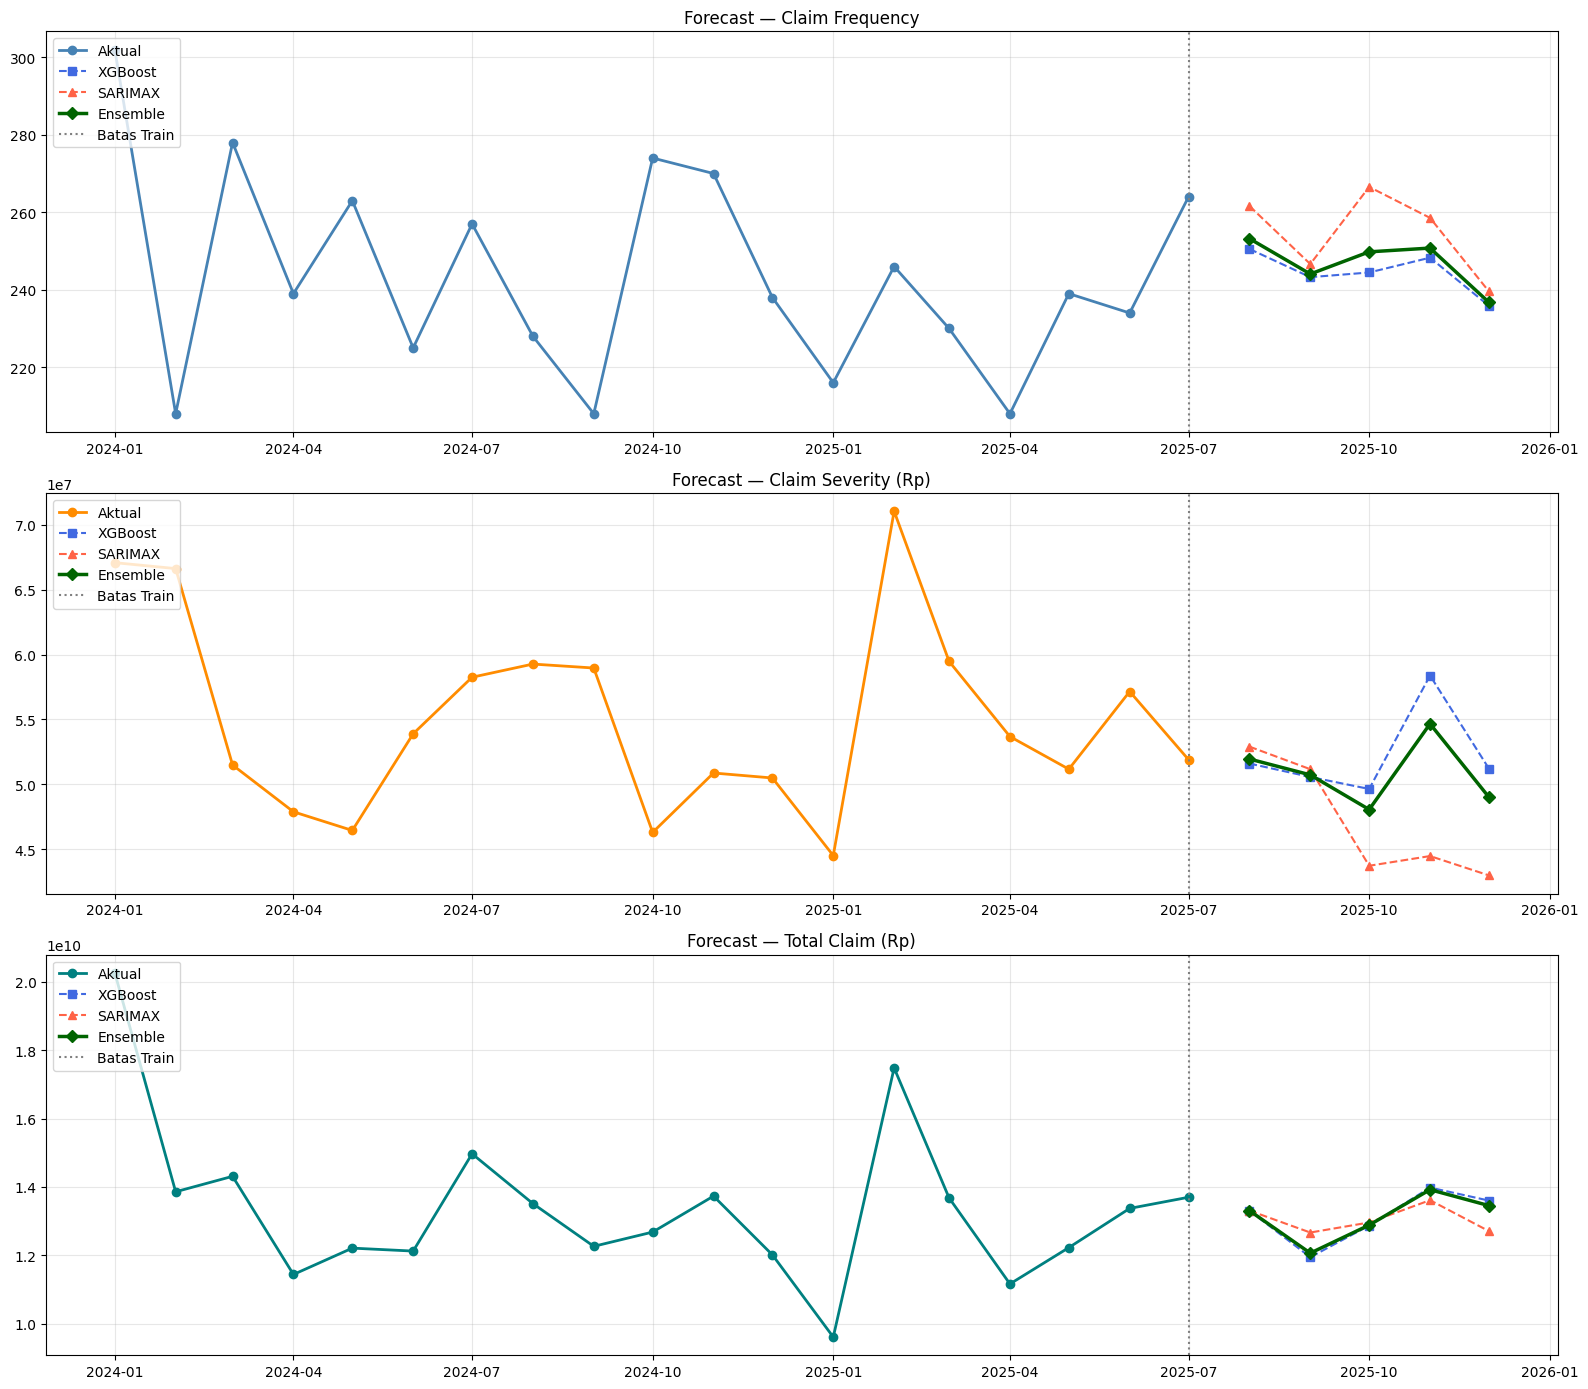


✅ Cell 9 selesai


In [34]:
# ── ENSEMBLE: WEIGHTED AVERAGE SARIMAX + XGBoost ──────
# Bobot ditentukan dari inverse MAPE walk-forward validation
# Semakin kecil MAPE → bobot lebih besar

print("=" * 50)
print("ENSEMBLE — Weighted Average SARIMAX + XGBoost")
print("=" * 50)

# MAPE dari walk-forward XGBoost (Cell 8)
mape_xgb_freq  = wf_results['Claim_Frequency']['MAPE']
mape_xgb_sev   = wf_results['Claim_Severity']['MAPE']
mape_xgb_total = wf_results['Total_Claim']['MAPE']

# In-sample MAPE SARIMAX sebagai proxy bobot
def get_sarimax_mape(sarimax_result, actual_series):
    fitted = np.array(sarimax_result.fittedvalues).flatten()
    actual = np.array(actual_series).flatten()
    
    # Samakan panjang (SARIMAX kadang beda panjang karena inisialisasi)
    min_len = min(len(fitted), len(actual))
    fitted  = fitted[-min_len:]
    actual  = actual[-min_len:]
    
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - fitted[mask]) / actual[mask])) * 100

mape_sarimax_freq  = get_sarimax_mape(
    sarimax_freq,  df_monthly['Claim_Frequency']
)
mape_sarimax_sev   = get_sarimax_mape(
    sarimax_sev,   df_monthly['Claim_Severity']
)
mape_sarimax_total = get_sarimax_mape(
    sarimax_total, df_monthly['Total_Claim']
)

print(f"\n  MAPE XGB   — Freq: {mape_xgb_freq:.2f}% | "
      f"Sev: {mape_xgb_sev:.2f}% | "
      f"Total: {mape_xgb_total:.2f}%")
print(f"  MAPE SARIMAX — Freq: {mape_sarimax_freq:.2f}% | "
      f"Sev: {mape_sarimax_sev:.2f}% | "
      f"Total: {mape_sarimax_total:.2f}%")

# Hitung bobot inverse MAPE
def inverse_mape_weights(mape_a, mape_b):
    """Bobot proporsional ke 1/MAPE"""
    w_a = (1 / mape_a) / (1 / mape_a + 1 / mape_b)
    w_b = (1 / mape_b) / (1 / mape_a + 1 / mape_b)
    return round(w_a, 4), round(w_b, 4)

w_xgb_freq,  w_sarimax_freq  = inverse_mape_weights(mape_xgb_freq,  mape_sarimax_freq)
w_xgb_sev,   w_sarimax_sev   = inverse_mape_weights(mape_xgb_sev,   mape_sarimax_sev)
w_xgb_total, w_sarimax_total = inverse_mape_weights(mape_xgb_total, mape_sarimax_total)

print(f"\n  Bobot XGB   — Freq: {w_xgb_freq} | "
      f"Sev: {w_xgb_sev} | "
      f"Total: {w_xgb_total}")
print(f"  Bobot SARIMAX — Freq: {w_sarimax_freq} | "
      f"Sev: {w_sarimax_sev} | "
      f"Total: {w_sarimax_total}")

# ── HITUNG ENSEMBLE FORECAST ───────────────────────────
df_forecast_final = pd.DataFrame({
    'Periode': future_periods
})

df_forecast_final['Freq_Ensemble'] = np.clip(
    w_xgb_freq  * df_forecast_xgb['Freq_XGB'].values +
    w_sarimax_freq * df_forecast_sarimax['Freq_SARIMAX'].values,
    a_min=0, a_max=None
)

df_forecast_final['Sev_Ensemble'] = np.clip(
    w_xgb_sev  * df_forecast_xgb['Sev_XGB'].values +
    w_sarimax_sev * df_forecast_sarimax['Sev_SARIMAX'].values,
    a_min=0, a_max=None
)

df_forecast_final['Total_Ensemble'] = np.clip(
    w_xgb_total  * df_forecast_xgb['Total_XGB'].values +
    w_sarimax_total * df_forecast_sarimax['Total_SARIMAX'].values,
    a_min=0, a_max=None
)

# Tambahkan kolom ID sesuai format Kaggle
months_id = ['2025-08', '2025-09', '2025-10', '2025-11', '2025-12']

print("\n" + "=" * 50)
print("FINAL ENSEMBLE FORECAST")
print("=" * 50)
display(df_forecast_final)

# ── PLOT FINAL FORECAST ────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

plot_configs = [
    ('Claim_Frequency', 'Freq_XGB',    'Freq_SARIMAX',  'Freq_Ensemble',
     'Claim Frequency', 'steelblue'),
    ('Claim_Severity',  'Sev_XGB',     'Sev_SARIMAX',   'Sev_Ensemble',
     'Claim Severity (Rp)',  'darkorange'),
    ('Total_Claim',     'Total_XGB',   'Total_SARIMAX', 'Total_Ensemble',
     'Total Claim (Rp)', 'teal'),
]

for i, (actual_col, xgb_col, sarimax_col,
        ensemble_col, title, color) in enumerate(plot_configs):

    # Actual
    axes[i].plot(
        df_monthly['Periode_Klaim'],
        df_monthly[actual_col],
        marker='o', color=color,
        linewidth=2, label='Aktual'
    )
    # XGB
    axes[i].plot(
        df_forecast_xgb['Periode'],
        df_forecast_xgb[xgb_col],
        marker='s', color='royalblue',
        linewidth=1.5, linestyle='--', label='XGBoost'
    )
    # SARIMAX
    axes[i].plot(
        df_forecast_sarimax['Periode'],
        df_forecast_sarimax[sarimax_col],
        marker='^', color='tomato',
        linewidth=1.5, linestyle='--', label='SARIMAX'
    )
    # Ensemble
    axes[i].plot(
        df_forecast_final['Periode'],
        df_forecast_final[ensemble_col],
        marker='D', color='darkgreen',
        linewidth=2.5, linestyle='-', label='Ensemble'
    )
    # Batas train
    axes[i].axvline(
        x=pd.Timestamp('2025-07-01'),
        color='gray', linestyle=':', linewidth=1.5,
        label='Batas Train'
    )
    axes[i].set_title(f'Forecast — {title}')
    axes[i].legend(loc='upper left')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Cell 9 selesai")

Kolom sample_submission: ['id', 'value']


,id,value
0,2025_08_Claim_Frequency,0
1,2025_08_Claim_Severity,0
2,2025_08_Total_Claim,0
3,2025_09_Claim_Frequency,0
4,2025_09_Claim_Severity,0
5,2025_09_Total_Claim,0
6,2025_10_Claim_Frequency,0
7,2025_10_Claim_Severity,0
8,2025_10_Total_Claim,0
9,2025_11_Claim_Frequency,0



✅ File 'submission_3.csv' siap disubmit!


,id,value
0,2025_08_Claim_Frequency,2.532013e+02
1,2025_08_Claim_Severity,5.194264e+07
2,2025_08_Total_Claim,1.330721e+10
3,2025_09_Claim_Frequency,2.440674e+02
4,2025_09_Claim_Severity,5.071834e+07
5,2025_09_Total_Claim,1.206522e+10
6,2025_10_Claim_Frequency,2.497844e+02
7,2025_10_Claim_Severity,4.804595e+07
8,2025_10_Total_Claim,1.288551e+10
9,2025_11_Claim_Frequency,2.507569e+02



EVALUASI PERFORMA — In-Sample (Jan–Jul 2025)

  XGBoost — MAPE Frequency  : 3.27%
  XGBoost — MAPE Severity   : 6.06%
  XGBoost — MAPE Total Claim: 7.57%
  XGBoost — MAPE Rata-rata  : 5.63%

PERBANDINGAN MODEL — Walk-Forward MAPE


,Model,MAPE_Freq,MAPE_Sev,MAPE_Total,MAPE_Avg
0,XGBoost,6.74,8.96,10.38,8.69
1,SARIMAX,21.22,24.54,52.53,32.76
2,Ensemble,13.98,16.75,31.45,20.73


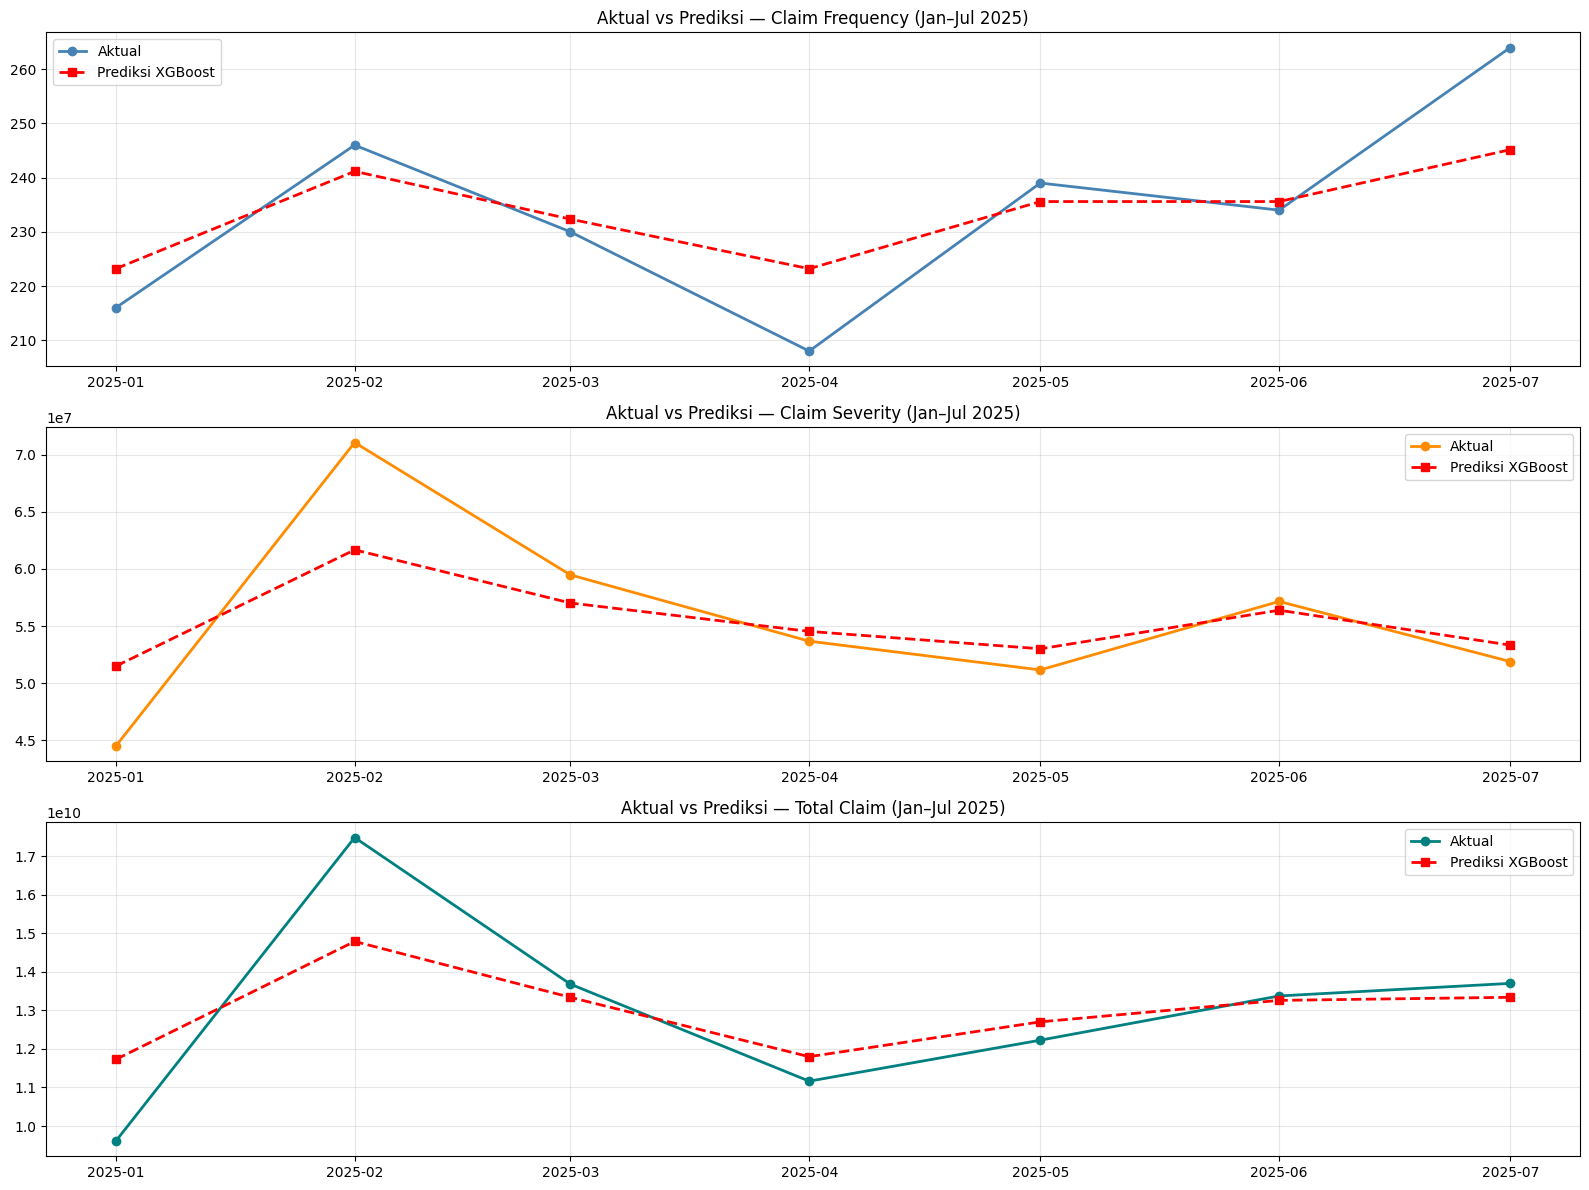


FINAL SUMMARY

  Total data training    : 19 bulan
  Periode training       : Jan 2024 — Jul 2025
  Periode forecast       : Agustus — Desember 2025
  Model digunakan        : XGBoost + SARIMAX (Ensemble)
  Metrik evaluasi        : MAPE (Walk-Forward Validation)

  Walk-Forward MAPE XGBoost:
    Frequency  : 6.74%
    Severity   : 8.96%
    Total Claim: 10.38%
    Rata-rata  : 8.69%

  Submission disimpan di : submission.csv

✅ Pipeline selesai — semua cell berhasil dijalankan


In [35]:
# ── KAGGLE SUBMISSION FORMAT ───────────────────────────
months_id = ['2025-08', '2025-09', '2025-10', '2025-11', '2025-12']

# ── KAGGLE SUBMISSION FORMAT ───────────────────────────

# Buat df_sub_data dari df_forecast_final
df_sub_data = pd.DataFrame({
    'Periode_Klaim'   : future_periods,
    'Claim_Frequency' : df_forecast_final['Freq_Ensemble'].values,
    'Claim_Severity'  : df_forecast_final['Sev_Ensemble'].values,
    'Total_Claim'     : df_forecast_final['Total_Ensemble'].values,
})

# Load sample submission
submission = pd.read_csv('sample_submission.csv')

print("Kolom sample_submission:", submission.columns.tolist())
display(submission.head(10))

# Fill submission sesuai format kaggle
for idx, row in df_sub_data.iterrows():
    month_str = row['Periode_Klaim'].strftime('%Y_%m')

    submission.loc[submission['id'] == f"{month_str}_Claim_Frequency", 'value'] = row['Claim_Frequency']
    submission.loc[submission['id'] == f"{month_str}_Claim_Severity",  'value'] = row['Claim_Severity']
    submission.loc[submission['id'] == f"{month_str}_Total_Claim",     'value'] = row['Total_Claim']

submission.to_csv('submission_3.csv', index=False)

print("\n✅ File 'submission_3.csv' siap disubmit!")
display(submission)

# ── EVALUASI PERFORMA MODEL ────────────────────────────
# Gunakan periode Jan 2025 – Jul 2025 sebagai pseudo test
# (data yang sudah ada) untuk menghitung MAPE aktual

print("\n" + "=" * 50)
print("EVALUASI PERFORMA — In-Sample (Jan–Jul 2025)")
print("=" * 50)

# Filter periode evaluasi
eval_df = df_monthly[
    df_monthly['Periode_Klaim'] >= '2025-01-01'
].copy().reset_index(drop=True)

eval_features = eval_df.dropna(subset=features)

if len(eval_features) > 0:
    X_eval = eval_features[features]

    # Prediksi XGBoost
    pred_freq_xgb  = xgb_freq.predict(X_eval)
    pred_sev_xgb   = xgb_sev.predict(X_eval)
    pred_total_xgb = xgb_total.predict(X_eval)

    # MAPE per model per target
    def safe_mape(actual, predicted):
        actual    = np.array(actual)
        predicted = np.array(predicted)
        mask      = actual != 0
        return np.mean(
            np.abs((actual[mask] - predicted[mask]) / actual[mask])
        ) * 100

    mape_eval_freq  = safe_mape(eval_features['Claim_Frequency'], pred_freq_xgb)
    mape_eval_sev   = safe_mape(eval_features['Claim_Severity'],  pred_sev_xgb)
    mape_eval_total = safe_mape(eval_features['Total_Claim'],     pred_total_xgb)

    print(f"\n  XGBoost — MAPE Frequency  : {mape_eval_freq:.2f}%")
    print(f"  XGBoost — MAPE Severity   : {mape_eval_sev:.2f}%")
    print(f"  XGBoost — MAPE Total Claim: {mape_eval_total:.2f}%")
    print(f"  XGBoost — MAPE Rata-rata  : "
          f"{np.mean([mape_eval_freq, mape_eval_sev, mape_eval_total]):.2f}%")

# ── TABEL PERBANDINGAN MODEL ───────────────────────────
print("\n" + "=" * 50)
print("PERBANDINGAN MODEL — Walk-Forward MAPE")
print("=" * 50)

comparison_df = pd.DataFrame({
    'Model'    : ['XGBoost', 'SARIMAX', 'Ensemble'],
    'MAPE_Freq': [
        round(mape_xgb_freq, 2),
        round(mape_sarimax_freq, 2),
        round((mape_xgb_freq + mape_sarimax_freq) / 2, 2)
    ],
    'MAPE_Sev' : [
        round(mape_xgb_sev, 2),
        round(mape_sarimax_sev, 2),
        round((mape_xgb_sev + mape_sarimax_sev) / 2, 2)
    ],
    'MAPE_Total': [
        round(mape_xgb_total, 2),
        round(mape_sarimax_total, 2),
        round((mape_xgb_total + mape_sarimax_total) / 2, 2)
    ],
})

comparison_df['MAPE_Avg'] = comparison_df[
    ['MAPE_Freq', 'MAPE_Sev', 'MAPE_Total']
].mean(axis=1).round(2)

display(comparison_df)

# ── VISUALISASI EVALUASI ───────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

eval_configs = [
    ('Claim_Frequency', pred_freq_xgb,  'Claim Frequency', 'steelblue'),
    ('Claim_Severity',  pred_sev_xgb,   'Claim Severity',  'darkorange'),
    ('Total_Claim',     pred_total_xgb, 'Total Claim',     'teal'),
]

for i, (actual_col, pred, title, color) in enumerate(eval_configs):
    if len(eval_features) > 0:
        axes[i].plot(
            eval_features['Periode_Klaim'],
            eval_features[actual_col],
            marker='o', color=color,
            linewidth=2, label='Aktual'
        )
        axes[i].plot(
            eval_features['Periode_Klaim'],
            pred,
            marker='s', color='red',
            linewidth=2, linestyle='--',
            label='Prediksi XGBoost'
        )
        axes[i].set_title(f'Aktual vs Prediksi — {title} (Jan–Jul 2025)')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── FINAL SUMMARY ─────────────────────────────────────
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(f"\n  Total data training    : {len(df_monthly)} bulan")
print(f"  Periode training       : "
      f"{df_monthly['Periode_Klaim'].min().strftime('%b %Y')} — "
      f"{df_monthly['Periode_Klaim'].max().strftime('%b %Y')}")
print(f"  Periode forecast       : Agustus — Desember 2025")
print(f"  Model digunakan        : XGBoost + SARIMAX (Ensemble)")
print(f"  Metrik evaluasi        : MAPE (Walk-Forward Validation)")
print(f"\n  Walk-Forward MAPE XGBoost:")
print(f"    Frequency  : {mape_xgb_freq:.2f}%")
print(f"    Severity   : {mape_xgb_sev:.2f}%")
print(f"    Total Claim: {mape_xgb_total:.2f}%")
print(f"    Rata-rata  : "
      f"{np.mean([mape_xgb_freq, mape_xgb_sev, mape_xgb_total]):.2f}%")
print(f"\n  Submission disimpan di : submission.csv")
print("\n✅ Pipeline selesai — semua cell berhasil dijalankan")